## 第五章 假设检验和回归分析

In [1]:
## 输出高清图像
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
## 图像显示中文的问题
import matplotlib
matplotlib.rcParams['axes.unicode_minus']=False

import seaborn as sns 
sns.set(font= "Kaiti",style="ticks",font_scale=1.4)

In [2]:
## 导入会使用到的相关库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy import stats
from scipy.optimize import curve_fit

from sklearn.preprocessing import QuantileTransformer,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,classification_report
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  Ridge,Lasso,LassoLars,ElasticNetCV,LogisticRegression,LogisticRegressionCV

from itertools import combinations
from pyearth import Earth

## 忽略提醒
import warnings
warnings.filterwarnings("ignore")

### 5.1 假设检验

#### 5.1.1 数据分布检验

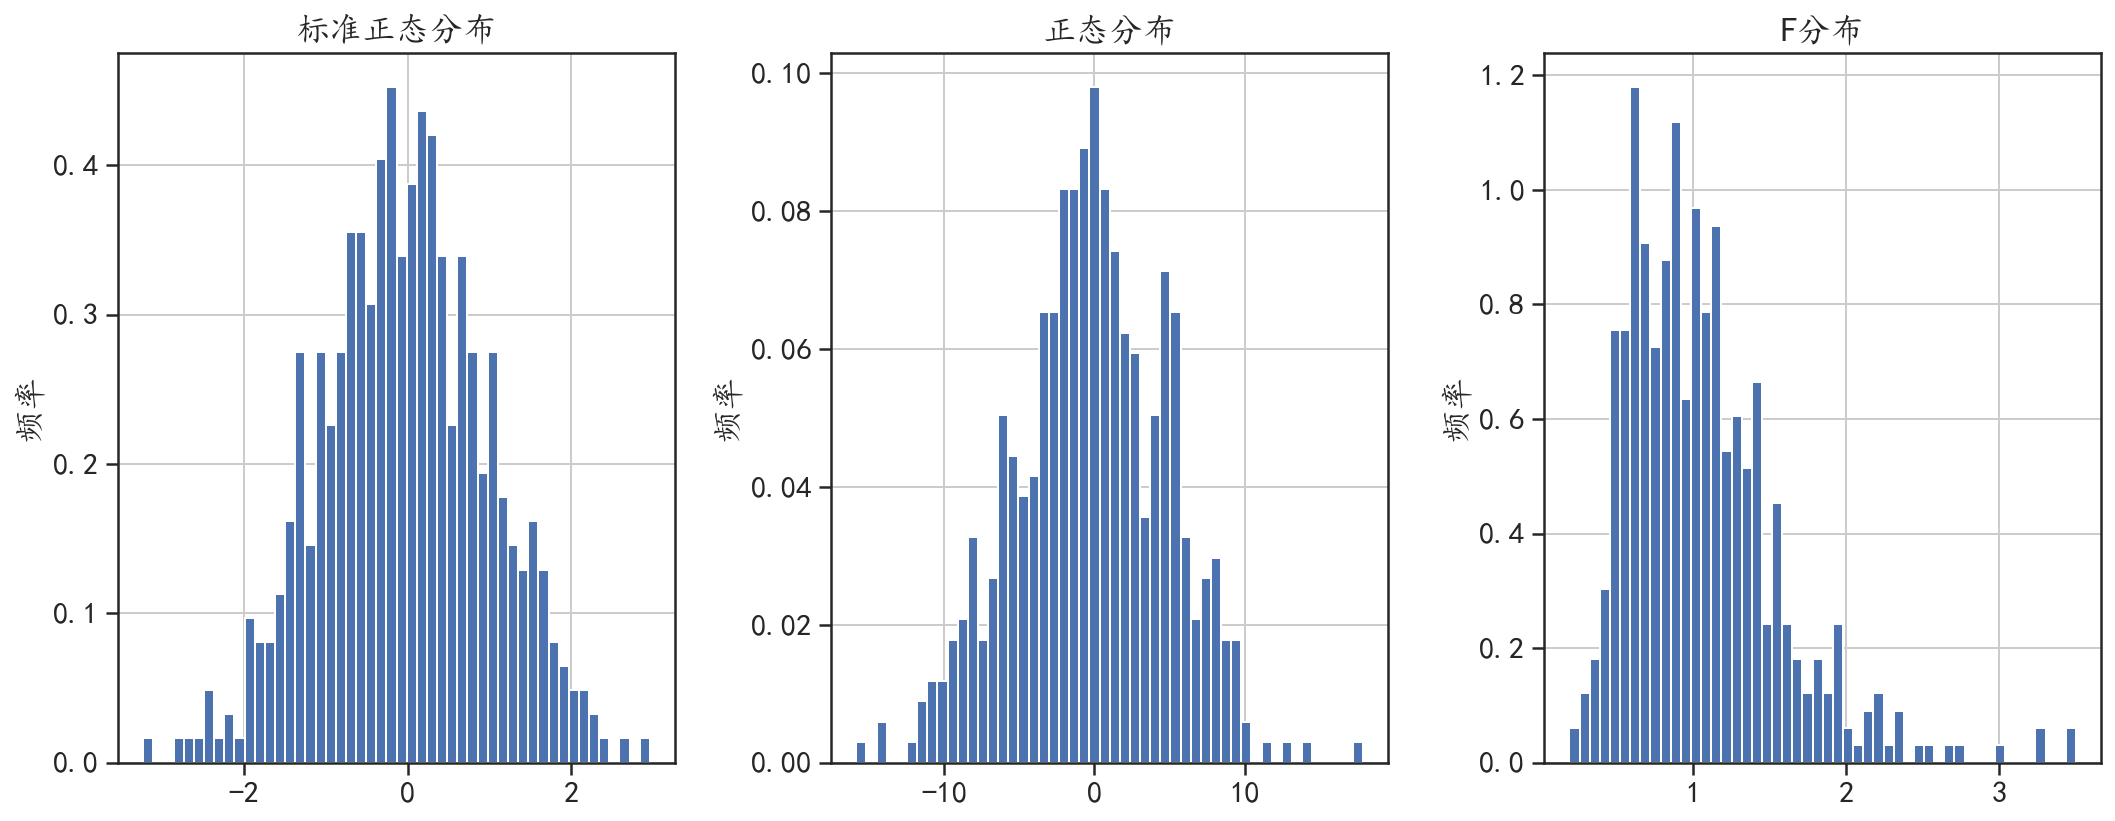

In [3]:
## 数据准备
np.random.seed(123)
## 生成标准正态分布随机数X1
X1 = stats.norm.rvs(loc = 0,scale = 1,size = 500)
## 生成正态分布随机数X2
X2 = stats.norm.rvs(loc = 0,scale = 5,size = 500)
## 生成F分布随机数X3
X3 = stats.f.rvs(15,30,size = 500)
## 利用直方图可视化两组数据的分布情况
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.hist(X1,bins=50,density=True)
plt.grid()
plt.ylabel("频率")
plt.title("标准正态分布")
plt.subplot(1,3,2)
plt.hist(X2,bins=50,density=True)
plt.grid()
plt.ylabel("频率")
plt.title("正态分布")
plt.subplot(1,3,3)
plt.hist(X3,bins=50,density=True)
plt.grid()
plt.ylabel("频率")
plt.title("F分布")
plt.tight_layout()
plt.show()

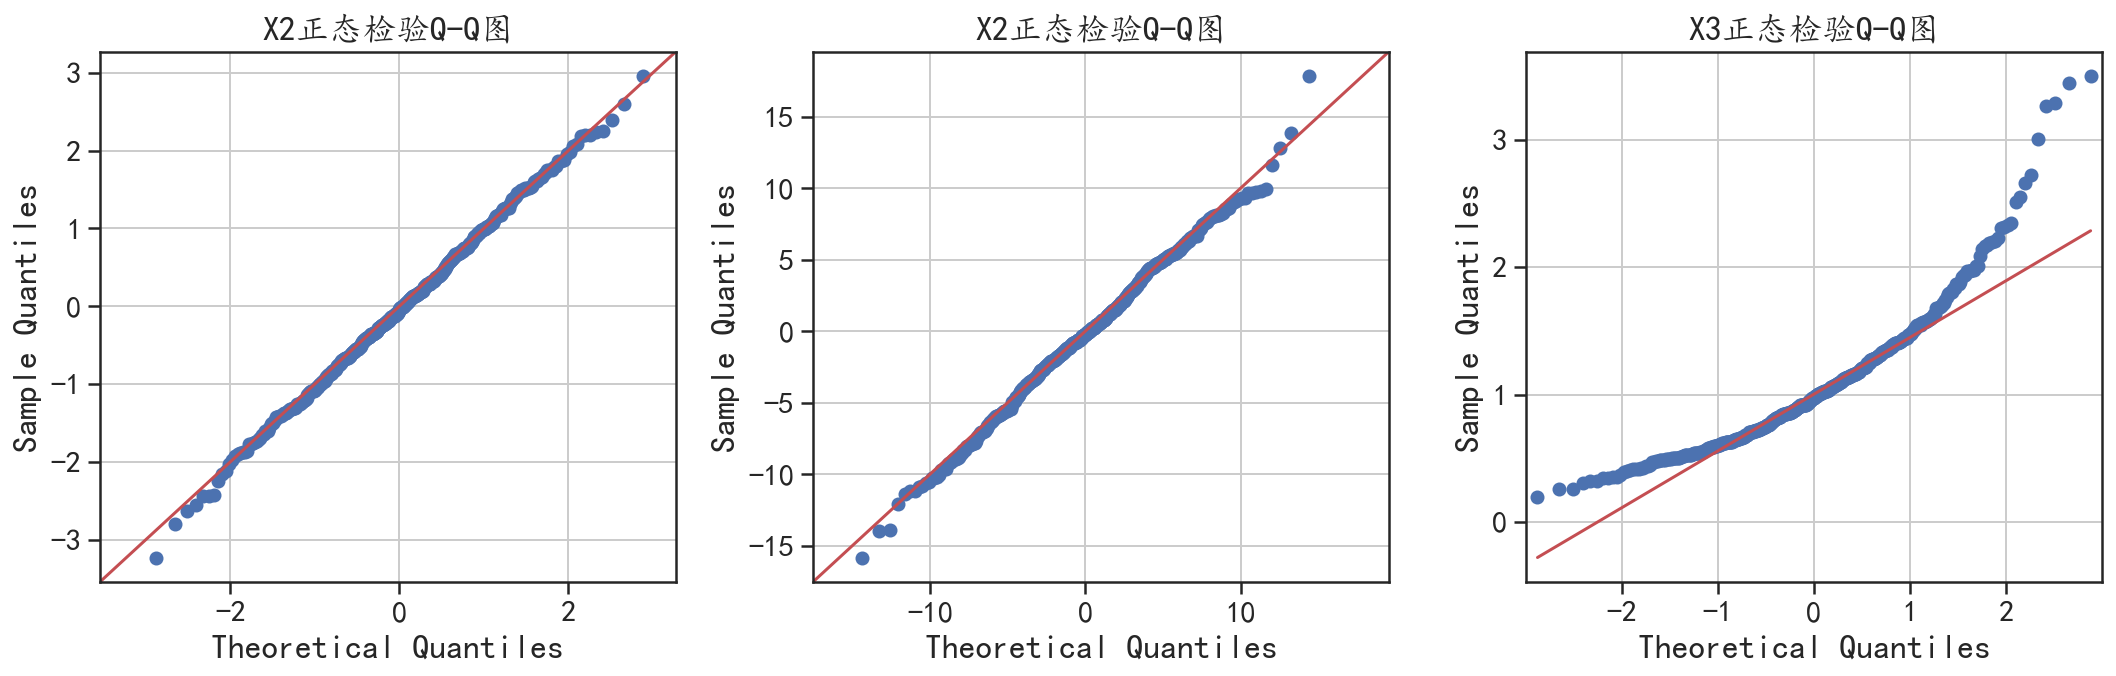

In [4]:
## 利用Q-Q图对两组数据进行正态性检验

fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(1,3,1)
## 默认检验标准正态分布，loc=0,scale=1
sm.qqplot(X1,line="45",ax = ax)
plt.grid()
plt.title("X2正态检验Q-Q图")

ax = fig.add_subplot(1,3,2)
## 指定正态分布的均值和标准差
sm.qqplot(X2,loc=0,scale=5,line="45",ax = ax)
plt.grid()
plt.title("X2正态检验Q-Q图")

ax = fig.add_subplot(1,3,3)
## 对F分布进行正态性检验
sm.qqplot(X3,line="q",ax = ax)
plt.grid()
plt.title("X3正态检验Q-Q图")
fig.tight_layout()
plt.show()


## 可发现，第一个图的散点图在图像的对角线上，表示数据X1是所标准正态分布
## 第二个图的散点图在图像的对角线上，表示数据X2是所指定的正态分布
## 第三个图的散点图不在图像的对角线上，表示数据X3不是正态分布

In [5]:
## K-S检验，可以指定所检验的数据分布类型
print("X1标准正态分布检验:\n",stats.kstest(X1,cdf = "norm"))
print("X2标准正态分布检验:\n",stats.kstest(X2,cdf = "norm"))
print("X2正态分布检验:\n",stats.kstest(X2,cdf = "norm",args = (0,5)))
print("X3标准正态分布检验:\n",stats.kstest(X3,cdf = "norm"))
print("X3 F(15,30)分布检验:\n",stats.kstest(X3,cdf = "f",args = (15,30)))

X1标准正态分布检验:
 KstestResult(statistic=0.030903709790884082, pvalue=0.714038602403839)
X2标准正态分布检验:
 KstestResult(statistic=0.3266532275656769, pvalue=5.2306133517677304e-48)
X2正态分布检验:
 KstestResult(statistic=0.03500755169583336, pvalue=0.5603023447098723)
X3标准正态分布检验:
 KstestResult(statistic=0.6369433974371657, pvalue=1.609080928303521e-197)
X3 F(15,30)分布检验:
 KstestResult(statistic=0.028179536785067155, pvalue=0.8112803981442576)


In [6]:
## K-S检验，检验两个数据之间的分布是否相同
print("X1和X2分布是否相同的检验:\n",stats.ks_2samp(X1,X2))
print("X1和X3分布是否相同的检验:\n",stats.ks_2samp(X1,X3))
print("X2和X3分布是否相同的检验:\n",stats.ks_2samp(X2,X3))

X1和X2分布是否相同的检验:
 KstestResult(statistic=0.328, pvalue=3.3583913478618886e-24)
X1和X3分布是否相同的检验:
 KstestResult(statistic=0.658, pvalue=1.175107982448385e-102)
X2和X3分布是否相同的检验:
 KstestResult(statistic=0.546, pvalue=9.273032713380692e-69)


####  5.1.2 t检验

In [7]:
## 数据准备
np.random.seed(123)
## 生成标准正态分布随机数X1
X1 = stats.norm.rvs(loc = 0,scale = 1,size = 500)
## 生成正态分布随机数X2
X2 = stats.norm.rvs(loc = 0,scale = 5,size = 500)
## 生成正态分布随机数X3
X3 = stats.norm.rvs(loc = 5,scale = 5,size = 500)

In [8]:
## 检验一个样本的均值是否为指定值
print("X1的均值是否等于0:\n",stats.ttest_1samp(X1,0))
print("X2的均值是否等于5:\n",stats.ttest_1samp(X2,5))
print("X3的均值是否等于5:\n",stats.ttest_1samp(X3,5))

## pvalue<0.05的检验表示可以拒绝均值等于指定值的原假设，表示均值不等于指定值

X1的均值是否等于0:
 Ttest_1sampResult(statistic=-0.8604849693780614, pvalue=0.3899350058490936)
X2的均值是否等于5:
 Ttest_1sampResult(statistic=-23.28071031299755, pvalue=1.0390149821456911e-81)
X3的均值是否等于5:
 Ttest_1sampResult(statistic=1.4552229249137607, pvalue=0.14623633901254982)


In [9]:
## 检验2个样本的均值是否为相等
print("X1和X2的均值是否相等:\n",stats.ttest_ind(X1,X2))
print("X1和X3的均值是否相等:\n",stats.ttest_ind(X1,X3))
print("X2和X3的均值是否相等:\n",stats.ttest_ind(X2,X3))

## pvalue<0.05的检验表示可以拒绝两样本均值相等的原假设，表示两个变量的平均值不项等

X1和X2的均值是否相等:
 Ttest_indResult(statistic=0.7185337922699782, pvalue=0.4725964034128529)
X1和X3的均值是否相等:
 Ttest_indResult(statistic=-25.450068546371313, pvalue=1.623506730435016e-110)
X2和X3的均值是否相等:
 Ttest_indResult(statistic=-18.145330653700995, pvalue=8.23954776165081e-64)


####  5.1.3 方差分析

In [10]:
## 单因素方差分析
## 使用鸢尾花数据来演示
Iris = pd.read_csv("data/chap3/Iris.csv")
print(Iris.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [11]:
## 比较不同种类的花下SepalLengthCm特征的均值是否相等
model = smf.ols("SepalLengthCm ~ Species", data=Iris).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

## P值远小于0.05，说明不同种类花的均值不完全相等，使用多重比较对比哪些花之间的均值不同

             sum_sq     df           F        PR(>F)
Species   63.212133    2.0  119.264502  1.669669e-31
Residual  38.956200  147.0         NaN           NaN


In [12]:
iris_hsd = pairwise_tukeyhsd(endog=Iris.SepalLengthCm,  #数据
                             groups=Iris.Species,       #分组
                             alpha = 0.05)              #显著性水平
print(iris_hsd)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1          group2     meandiff p-adj lower  upper  reject
-------------------------------------------------------------------
    Iris-setosa Iris-versicolor     0.93 0.001 0.6862 1.1738   True
    Iris-setosa  Iris-virginica    1.582 0.001 1.3382 1.8258   True
Iris-versicolor  Iris-virginica    0.652 0.001 0.4082 0.8958   True
-------------------------------------------------------------------


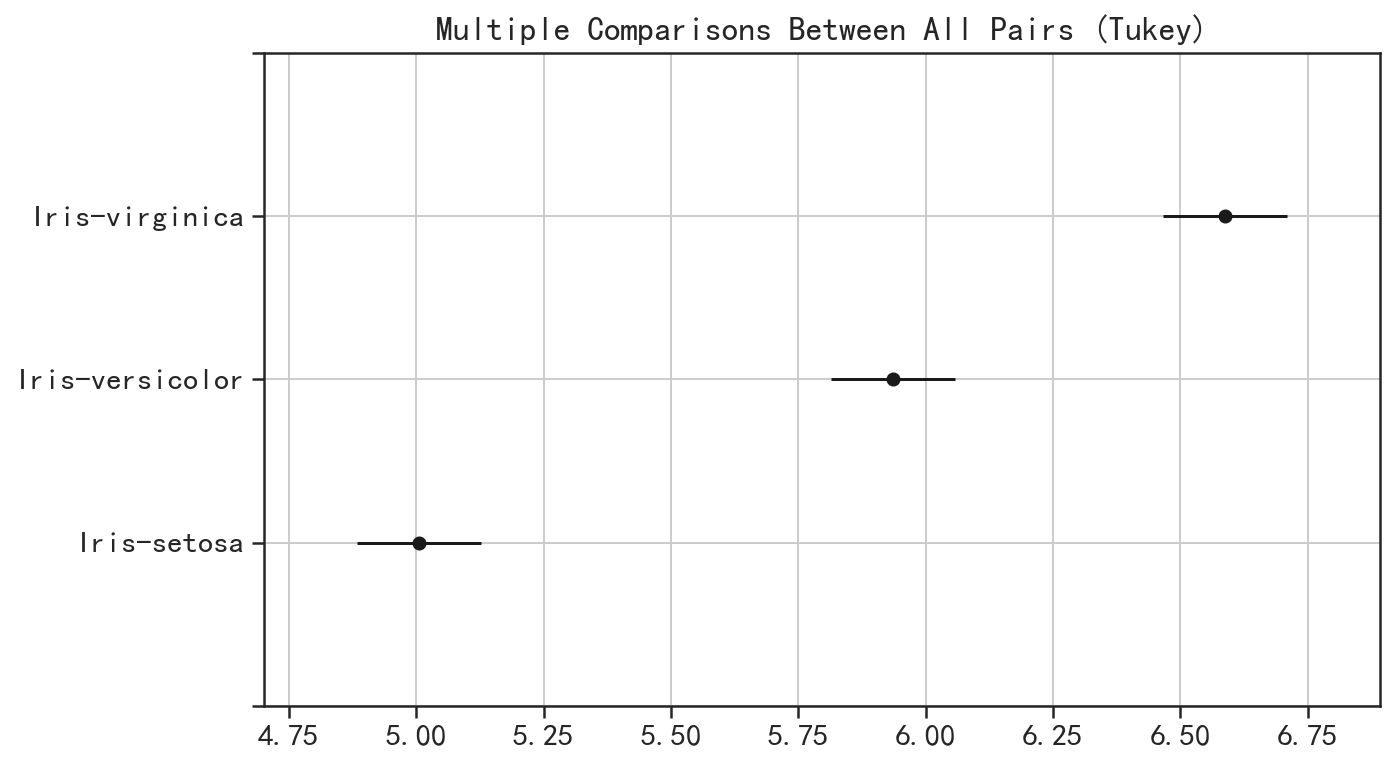

In [13]:
## 可视化出对比图像
iris_hsd.plot_simultaneous()
plt.grid()
plt.show()

In [14]:
##  多因素方差分析（2因素方差分析）
## 为鸢尾花生成一个新的随机分组变量
np.random.seed(123)
Iris["Group"] = np.random.choice(["A","B"],size = 150)
## 比较不同种类的花下SepalLengthCm特征的均值是否相等
model = smf.ols("SepalLengthCm ~ Species * Group", data=Iris).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

## 从结果中可发现，Species下差异是显著的；Group和Species:Group下差异是不显著的

                  sum_sq     df           F        PR(>F)
Species        60.182055    2.0  113.784895  2.286604e-30
Group           0.687846    1.0    2.600992  1.089863e-01
Species:Group   0.186779    2.0    0.353139  7.030862e-01
Residual       38.081575  144.0         NaN           NaN


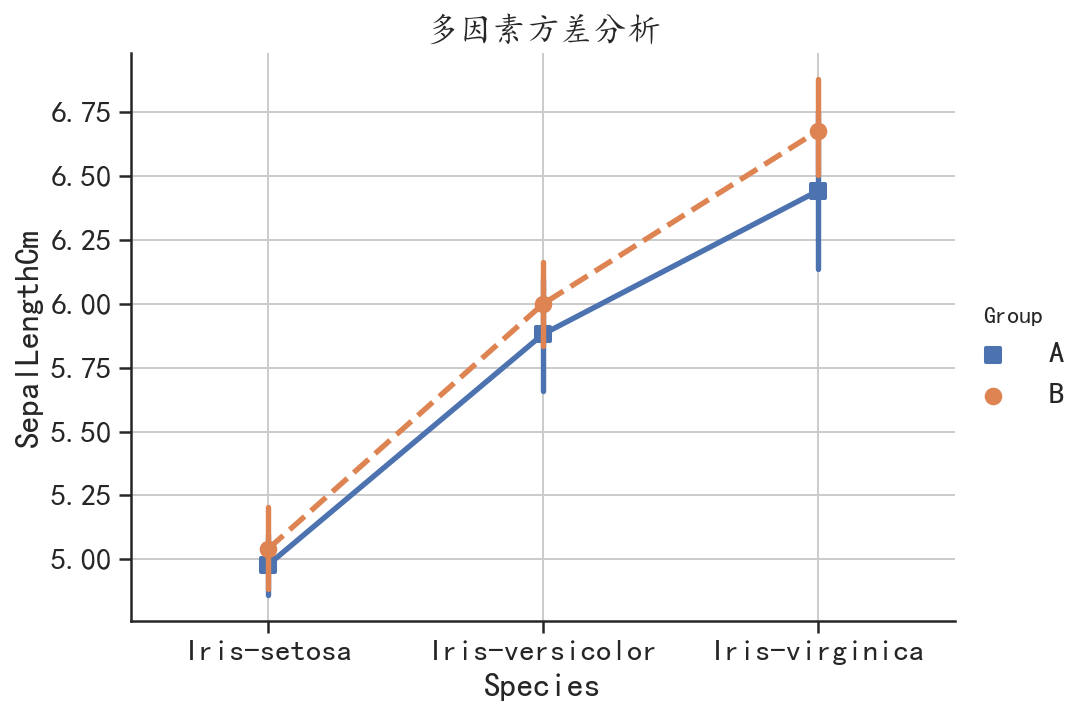

In [15]:
## 使用pointplot可视化不同分组数据之间均值的差异
sns.catplot(x="Species", y="SepalLengthCm",hue="Group",
            markers=["s", "o"], linestyles=["-", "--"],
            kind="point", data=Iris,
            height=5,aspect=1.4)  # 调整图像大小
plt.grid()
plt.title("多因素方差分析")
plt.show()

### 5.2 一元回归分析

#### 5.2.1 一元线性回归

In [16]:
## 读取数据
Iris = pd.read_csv("data/chap3/Iris.csv")
## 建立一元线性回归模型
lm1 = smf.ols("PetalWidthCm ~ PetalLengthCm",data=Iris).fit()
print(lm1.summary())

## 方差分析结果显示模型是显著的，t检验表明变量的系数是显著的

                            OLS Regression Results                            
Dep. Variable:           PetalWidthCm   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     1877.
Date:                Tue, 25 Aug 2020   Prob (F-statistic):           5.78e-86
Time:                        12:51:10   Log-Likelihood:                 24.400
No. Observations:                 150   AIC:                            -44.80
Df Residuals:                     148   BIC:                            -38.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.3665      0.040     -9.188

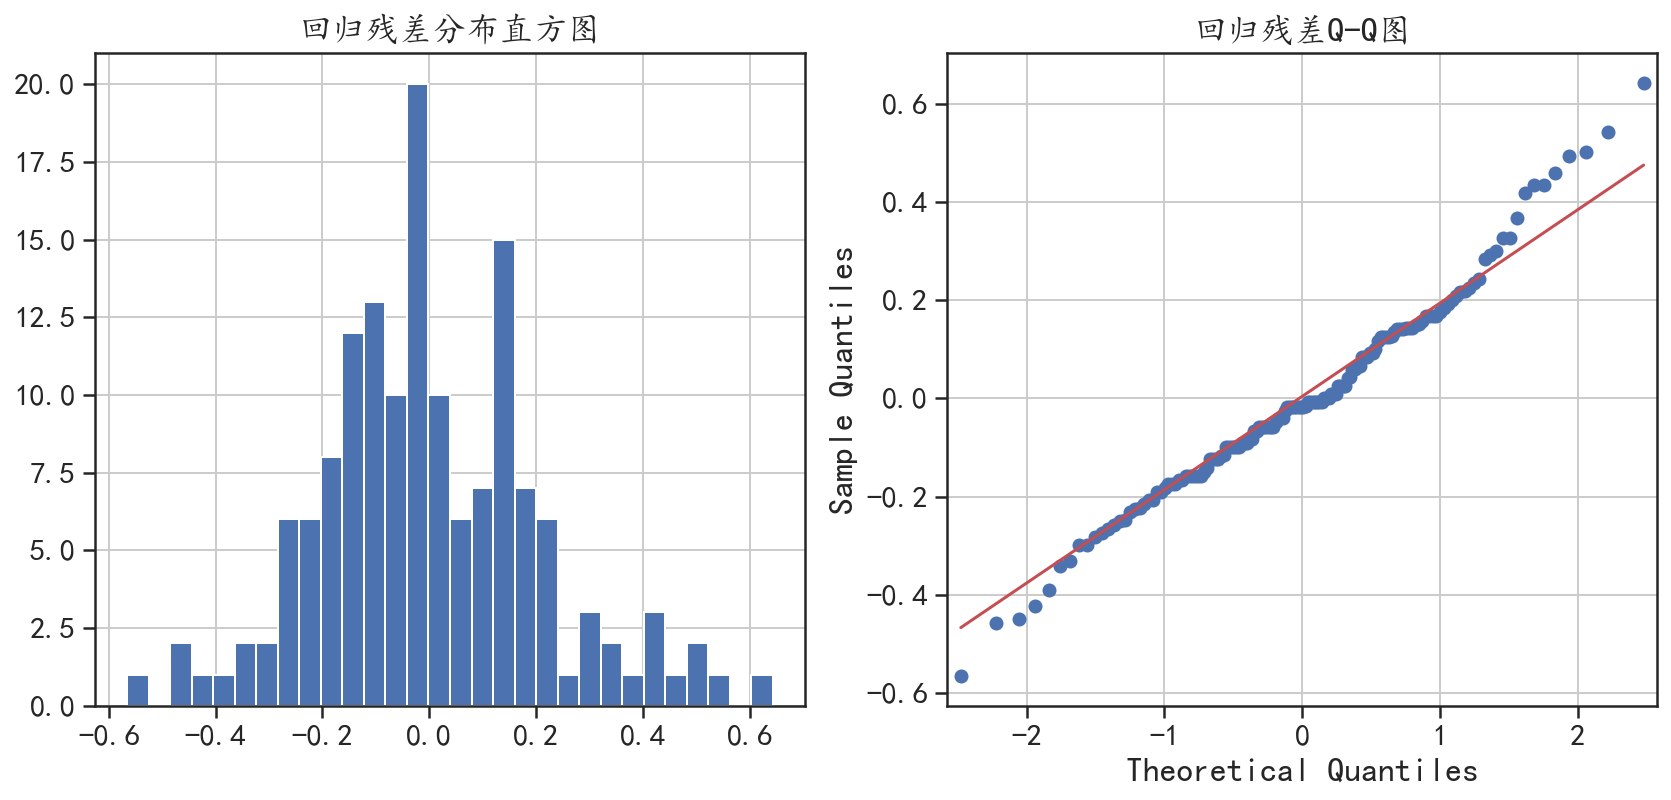

In [17]:
## 可视化获取拟合模型的残差分布
fig = plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.hist(lm1.resid,bins=30)
plt.grid()
plt.title("回归残差分布直方图")
ax = fig.add_subplot(1,2,2)
sm.qqplot(lm1.resid,line="q",ax = ax)
plt.grid()
plt.title("回归残差Q-Q图")
plt.show()

## 从可视化结果汇总可知，回归模型的拟合残差值符合正态分布

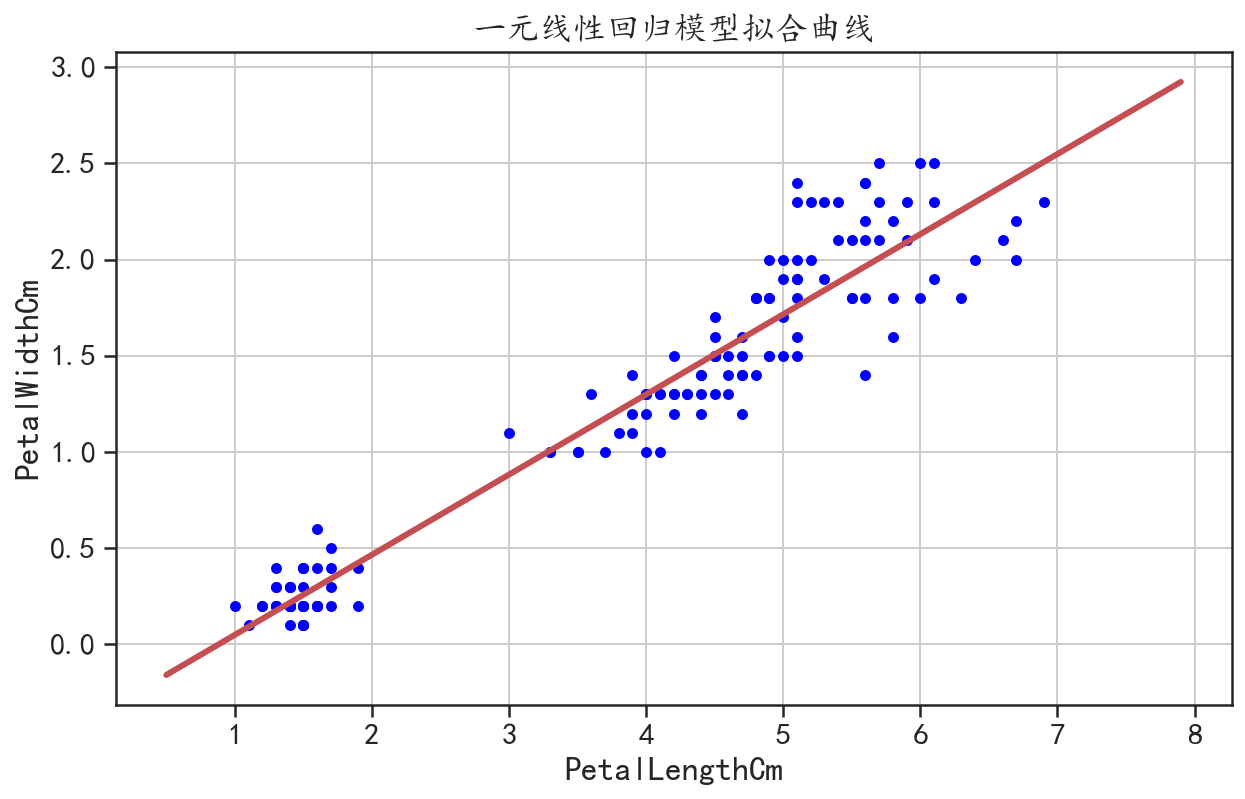

In [18]:
## 对数据取值进行预测
X = pd.DataFrame(data = np.arange(0.5,8,step = 0.1),
                 columns= ["PetalLengthCm"])
Y = lm1.predict(X)  # 使用一元回归模型获取预测值
## 可视化两个变量之间的关系和获得的回归模型曲线
Iris.plot(kind = "scatter",x="PetalLengthCm",y = "PetalWidthCm",
          c = "blue",figsize=(10,6))
plt.plot(X,Y,"r-",linewidth = 3)
plt.grid()
plt.title("一元线性回归模型拟合曲线")
plt.show()

####  5.2.2 一元非线性回归


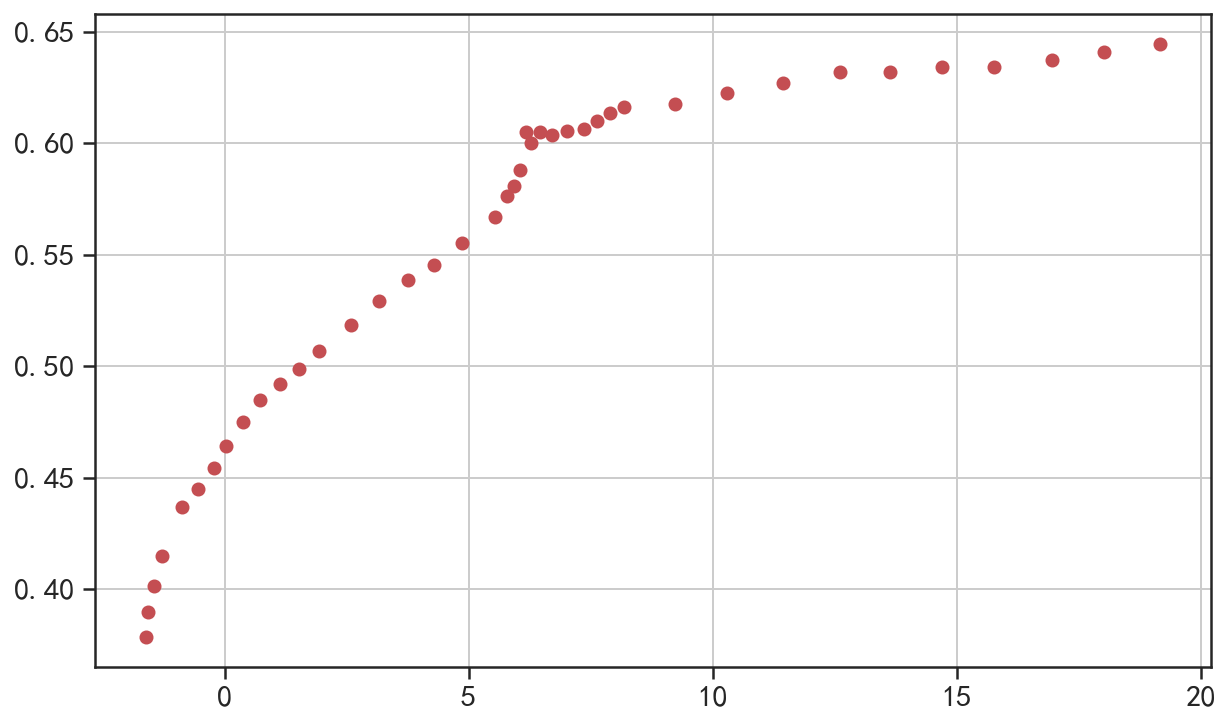

In [19]:
## 读取数据
xydf = pd.read_csv("data/chap5/xydata.csv")
## 对数据进行可视化
plt.figure(figsize=(10,6))
plt.plot(xydf.x,xydf.y,"ro")
plt.grid()
plt.show()

## 经观察图像的趋势更像一个指数函数


In [20]:
## 定义一个非线性方程
def func1(x, a, b, c):
    return a * np.exp(-b * x) + c
## 使用curve_fit函数进行方程的拟合
popt, pcov = curve_fit(func1,xydf.x,xydf.y)
print("a,b,c的估计值为:",popt)

a,b,c的估计值为: [-0.19472165  0.17792023  0.65242412]


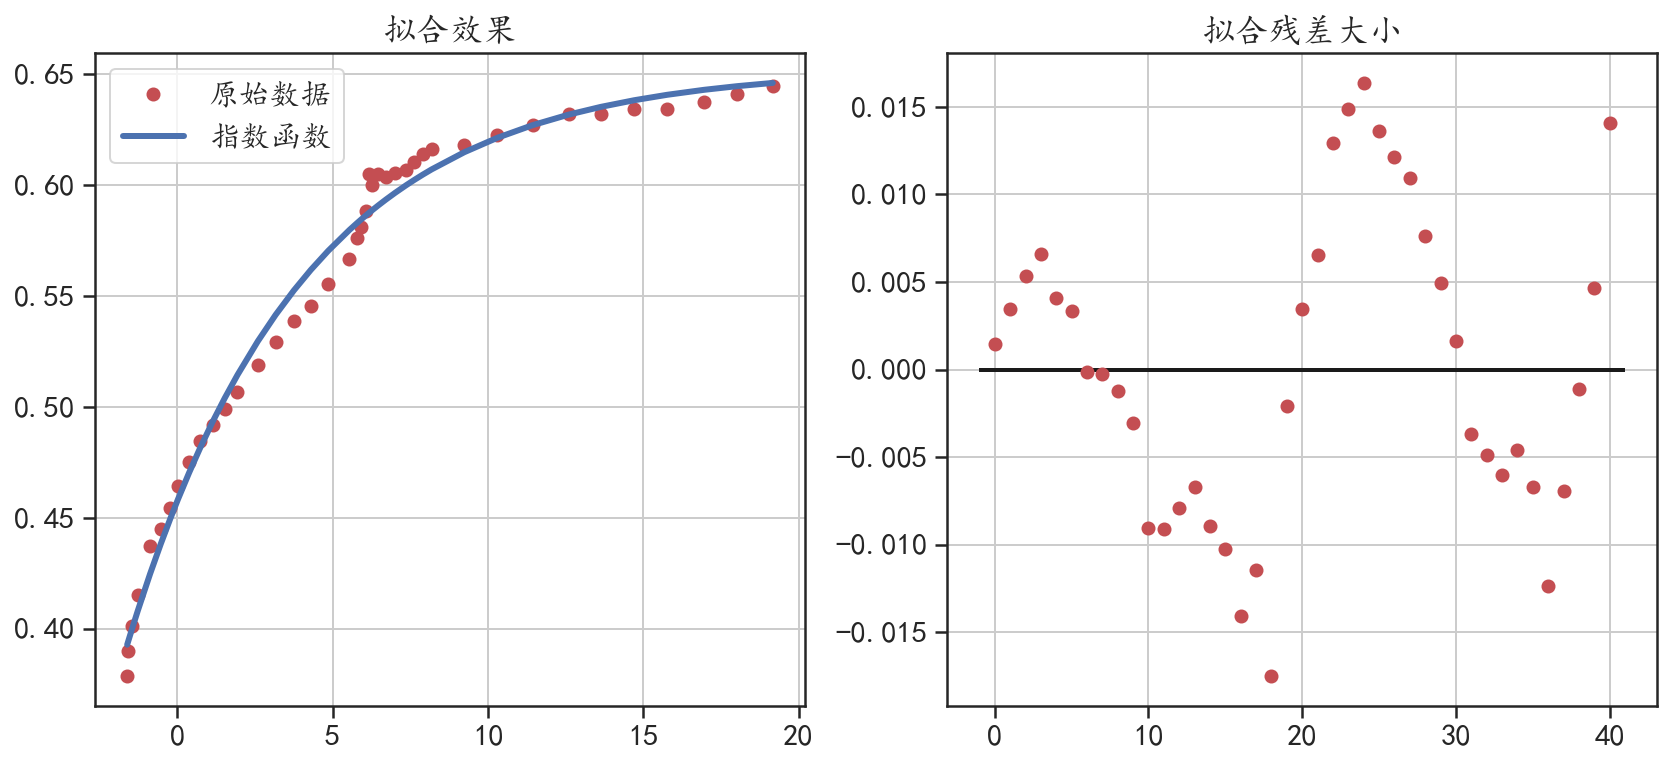

In [21]:
## 计算模型对原始数据的拟合结果
a = popt[0]
b = popt[1]
c = popt[2]
fit_y = func1(xydf.x,a,b,c)
## 计算拟合残差
res1 = fit_y - xydf.y
## 同时可视化原始数据和方程的拟合值
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(xydf.x,xydf.y,"ro",label = "原始数据")
plt.plot(xydf.x,fit_y,"b-",linewidth = 3,label = "指数函数")
plt.grid()
plt.legend()
plt.title("拟合效果")
## 可视化拟合残差的大小
plt.subplot(1,2,2)
plt.plot(res1,"ro")
plt.hlines(y = 0,xmin=-1,xmax = 41,linewidth = 2)
plt.grid()
plt.title("拟合残差大小")
plt.show()

In [22]:
## 使用二次函数进行拟合
def func2(x, a, b, c):
    return a * x**2 + b * x + c
## 使用curve_fit函数进行方程的拟合
popt, pcov = curve_fit(func2,xydf.x,xydf.y)
print("a,b,c的估计值为:",popt)

a,b,c的估计值为: [-0.00097756  0.02748129  0.45395542]


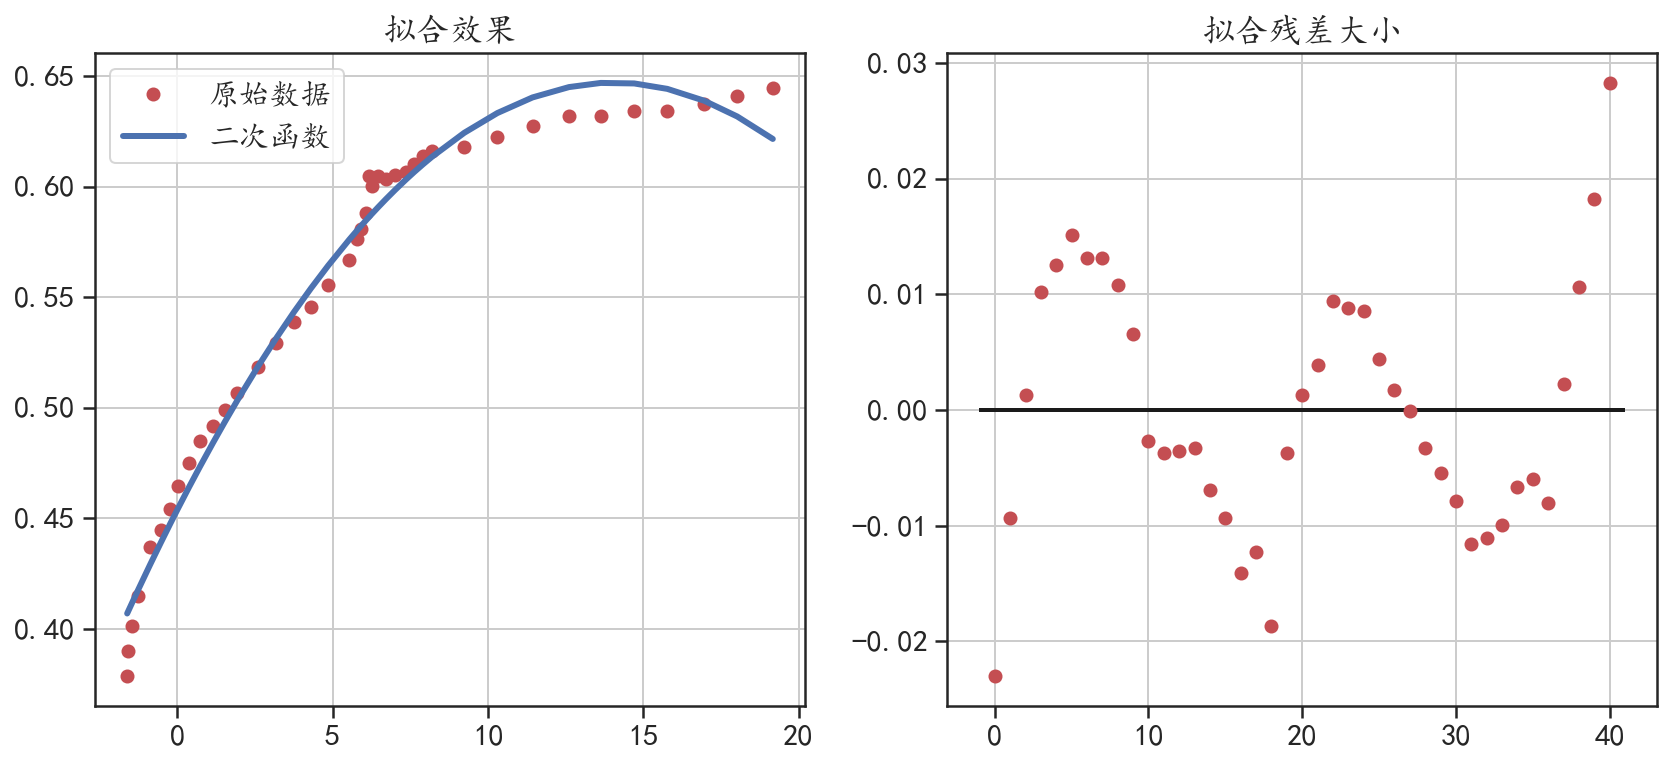

In [23]:
## 计算模型对原始数据的拟合结果
a = popt[0]
b = popt[1]
c = popt[2]
fit_y = func2(xydf.x,a,b,c)
## 计算拟合残差
res1 = fit_y - xydf.y
## 同时可视化原始数据和方程的拟合值
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(xydf.x,xydf.y,"ro",label = "原始数据")
plt.plot(xydf.x,fit_y,"b-",linewidth = 3,label = "二次函数")
plt.grid()
plt.legend()
plt.title("拟合效果")
## 可视化拟合残差的大小
plt.subplot(1,2,2)
plt.plot(res1,"ro")
plt.hlines(y = 0,xmin=-1,xmax = 41,linewidth = 2)
plt.grid()
plt.title("拟合残差大小")
plt.show()

In [24]:
## 很明显使用指数函数对数据进行拟合的效果比使用二次函数更好

### 5.3 多元回归分析
 

#### 数据探索和准备

In [25]:
## 读取用于多元回归的数据
enbdf = pd.read_excel("data/chap5/ENB2012.xlsx") 
## 对每个变量的取值进行标准化
enbdf_n = (enbdf-enbdf.mean())/enbdf.std()
enbdf_n.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-1.340767,-1.7593,-1.813393,-0.669679
1,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.446922,-1.7593,-1.813393,-0.669679
2,2.040447,-1.784712,-0.561586,-1.469119,0.999349,0.446922,-1.7593,-1.813393,-0.669679
3,2.040447,-1.784712,-0.561586,-1.469119,0.999349,1.340767,-1.7593,-1.813393,-0.669679
4,1.284142,-1.228438,0.000000,-1.197897,0.999349,-1.340767,-1.7593,-1.813393,-0.145408


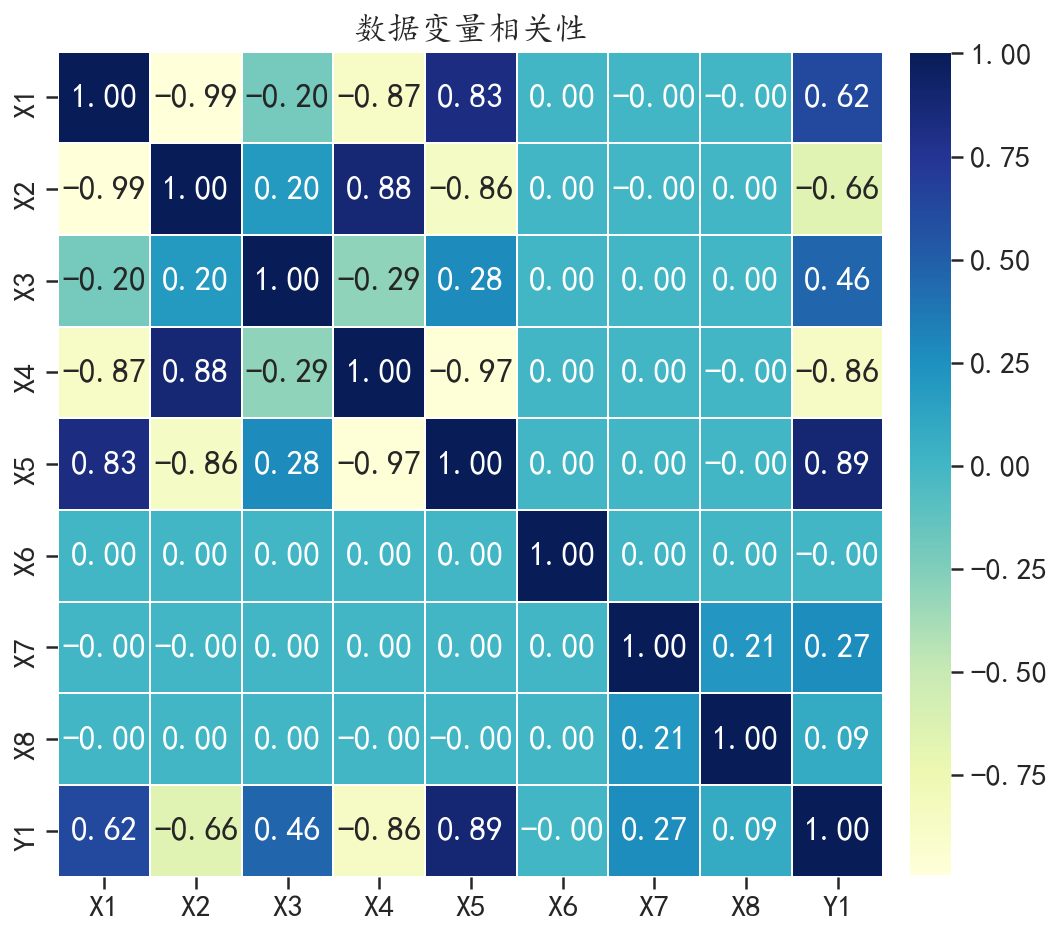

In [26]:
## 使用相关系数热力图可视化特征之间的相关性
datacor = enbdf_n.corr()  ## 计算相关系数
## 热力图可视化相关系数
plt.figure(figsize=(8,8))
ax = sns.heatmap(datacor,square=True,annot=True,fmt = ".2f",
                 linewidths=.5,cmap="YlGnBu",
                 cbar_kws={"fraction":0.046, "pad":0.03})
ax.set_title("数据变量相关性")
plt.show()

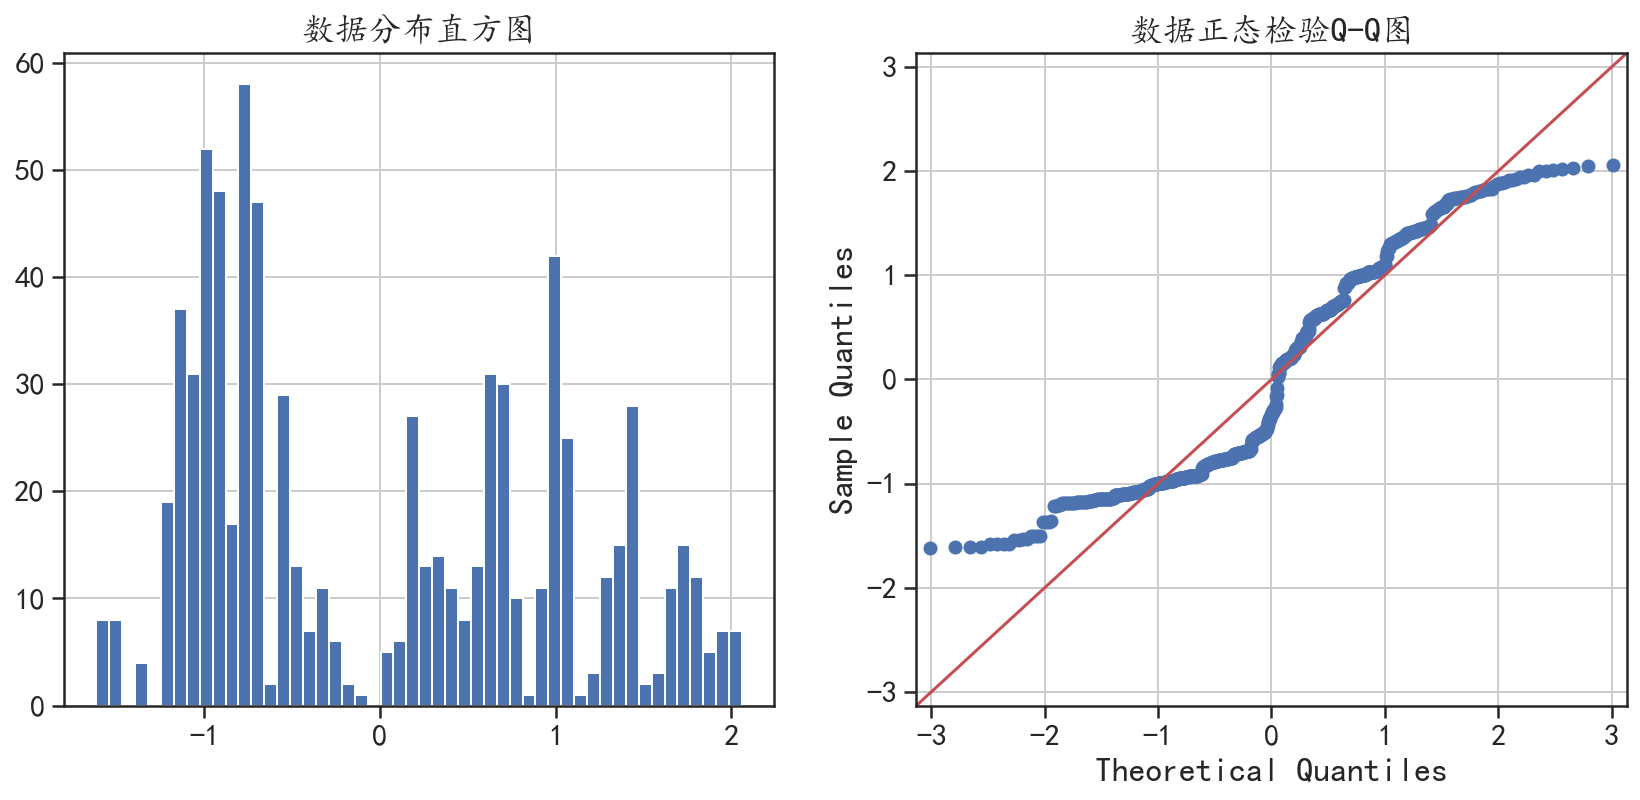

In [27]:
## 可视化因变量Y1的数据分布
fig = plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.hist(enbdf_n.Y1,bins=50)
plt.grid()
plt.title("数据分布直方图")
ax = fig.add_subplot(1,2,2)
sm.qqplot(enbdf_n.Y1,line="45",ax = ax)
plt.grid()
plt.title("数据正态检验Q-Q图")
plt.show()

## 可以发现因变量Y1不是正太分布的，下面将其转化为正态分布

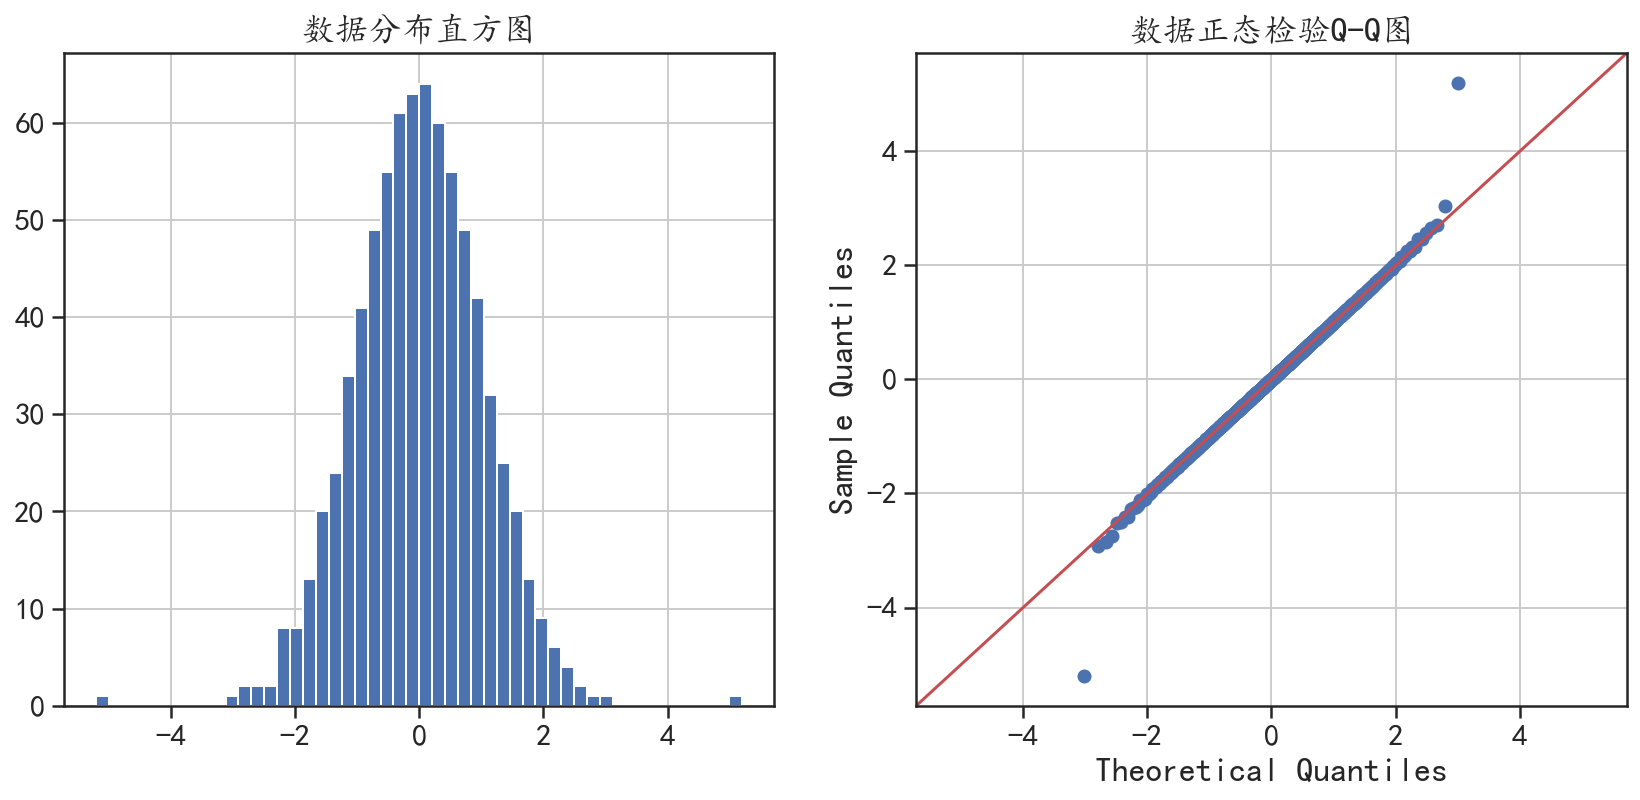

In [28]:
## 数据变换方法为QuantileTransformer
QT = QuantileTransformer(n_quantiles = 500,output_distribution="normal", random_state=12)
enbdf_n["Y"] = QT.fit_transform(enbdf_n.Y1.values.reshape(-1,1))
## 可视化变换后的因变量
fig = plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.hist(enbdf_n.Y,bins=50)
plt.grid()
plt.title("数据分布直方图")
ax = fig.add_subplot(1,2,2)
sm.qqplot(enbdf_n.Y,line="45",ax = ax)
plt.grid()
plt.title("数据正态检验Q-Q图")
plt.show()

## 可以发现变换后数据因变量Y属于标准正态分布

#### 5.3.1 多元线性回归


In [29]:
## 多元回归
formula = "Y ~ X1 + X2 + X3 + X4 + X5+ X6 + X7 + X8"
lm = smf.ols(formula, enbdf_n).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     642.8
Date:                Tue, 25 Aug 2020   Prob (F-statistic):          3.27e-314
Time:                        12:51:13   Log-Likelihood:                -366.65
No. Observations:                 768   AIC:                             749.3
Df Residuals:                     760   BIC:                             786.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -4.25e-05      0.014     -0.003      0.9

In [30]:
## 回归结果表示模型中可能存在多重共线性问题，条件数为3.89e+16取值很大
## 自变量X1，X4，X6是不显著的

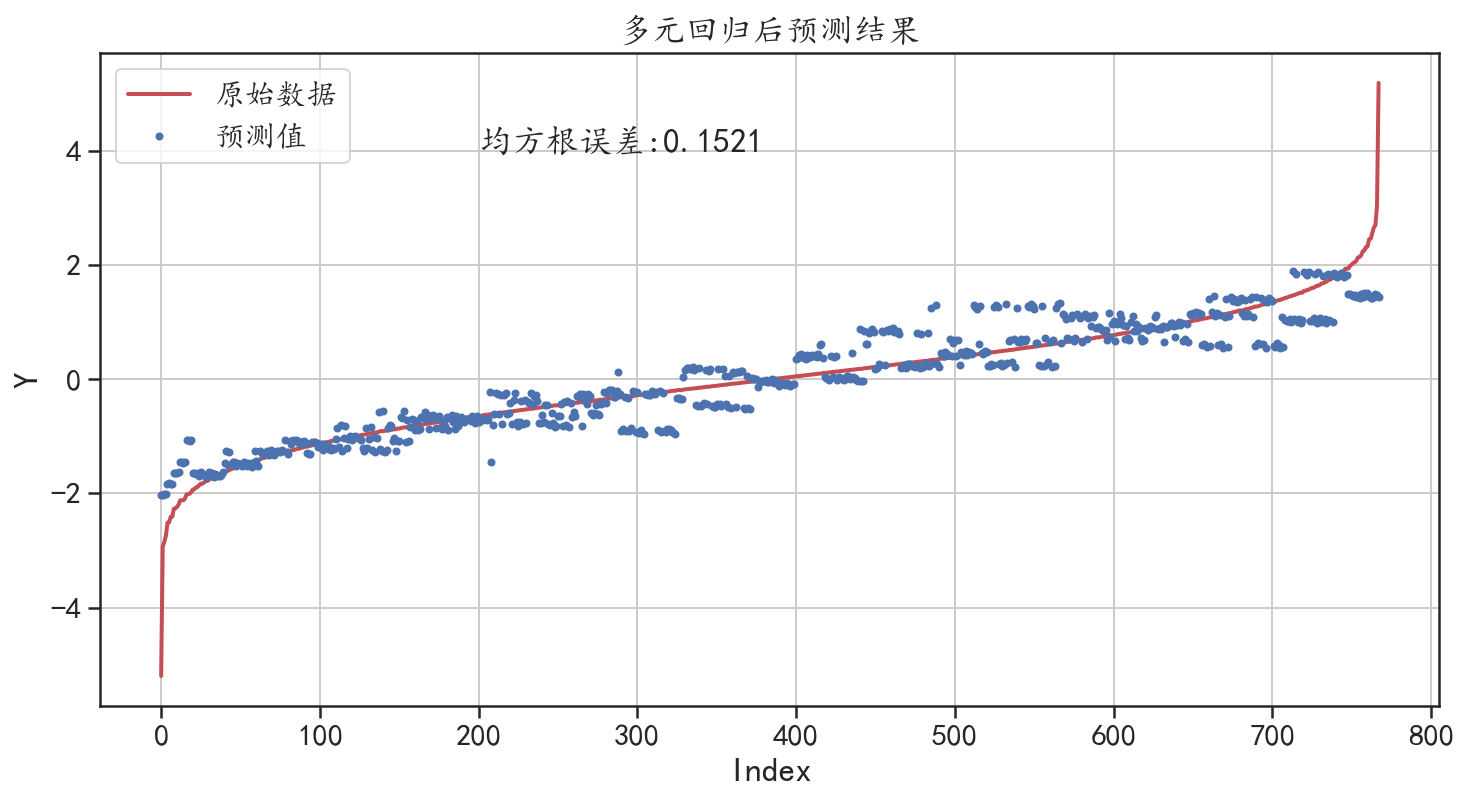

In [31]:
## 绘制回归的预测结果和原始数据的差异
Y_pre = lm.predict(enbdf_n)
rmse = round(mean_squared_error(enbdf_n.Y,Y_pre),4)
index = np.argsort(enbdf_n.Y)
plt.figure(figsize=(12,6))
plt.plot(np.arange(enbdf_n.shape[0]),enbdf_n.Y[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(enbdf_n.shape[0]),Y_pre[index],"bo",
         markersize=3,label = "预测值")
plt.text(200,4,s = "均方根误差:"+str(rmse))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("多元回归后预测结果")
plt.show()

In [32]:
## 剔除 abs(Y) > 4的异常值样本进行回归分析
## 多元回归
formula = "Y ~ X1 + X2 + X3 + X4 + X5+ X6 + X7 + X8"
enbdf_new = enbdf_n[enbdf_n.Y.abs() < 4]
enbdf_new = enbdf_new.reset_index(drop=True)
lm2 = smf.ols(formula, enbdf_new).fit()
print(lm2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     776.3
Date:                Tue, 25 Aug 2020   Prob (F-statistic):               0.00
Time:                        12:51:13   Log-Likelihood:                -276.67
No. Observations:                 766   AIC:                             569.3
Df Residuals:                     758   BIC:                             606.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0008      0.013     -0.060      0.9

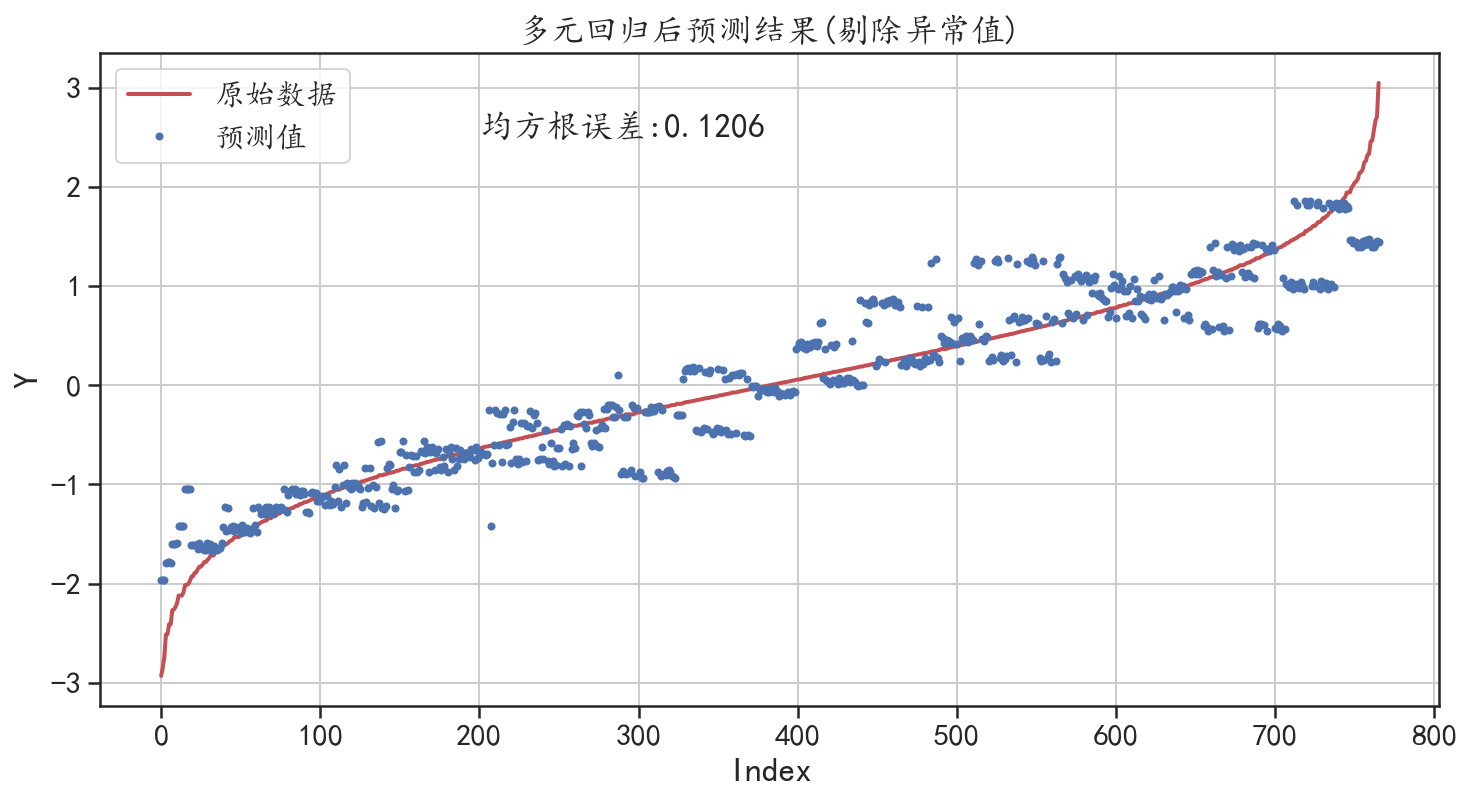

In [33]:
## 绘制回归的预测结果和原始数据的差异
Y_pre = lm2.predict(enbdf_new)
rmse = round(mean_squared_error(enbdf_new.Y,Y_pre),4)
index = np.argsort(enbdf_new.Y)
plt.figure(figsize=(12,6))
plt.plot(np.arange(enbdf_new.shape[0]),enbdf_new.Y[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(enbdf_new.shape[0]),Y_pre[index],"bo",
         markersize=3,label = "预测值")
plt.text(200,2.5,s = "均方根误差:"+str(rmse))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("多元回归后预测结果(剔除异常值)")
plt.show()

####  5.3.2 逐步回归

In [34]:
## 利用逐步回归对多元回归方程中的不显著变量进行挑选
Enb = enbdf_new.drop(labels=["Y1"],axis=1)   ## 删除数据中的Y1变量
## 根据BIC和Cond. No.（条件数）根据参与回归的自变量个数来找到合适的回归模型
variable = []
aic = []
bic = []
Cond = []
R_squared = []
## 第一次循环获取所有的变量组合
for ii in range(1,len(Enb.columns.values[0:-1])):
    var = list(combinations(Enb.columns.values[0:-2],ii))
    ## 第二次循环为每个变量组合进行回归分析
    for v in var:
        formulav = "Y"+"~"+"+".join(v)
        lm = smf.ols(formulav, Enb).fit()
        bic.append(lm.bic)
        aic.append(lm.aic)
        variable.append(v)
        Cond.append(lm.condition_number)
        R_squared.append(lm.rsquared)
## 将输出的结果整理为数据表格
df = pd.DataFrame()
df["variable"] = variable
df["bic"] = bic
df["aic"] = aic
df["Cond"] = Cond
df["R_squared"] = R_squared

In [35]:
## 将输出的参数根据bic排序,并且条件数较小的变量组合
df.sort_values("bic",ascending=True)[df.Cond<300].head(8)

## 可以发现bicd最小的回归方程只用到了(X2, X3, X5, X7)4个自变量，并且R2 ＝0.87675
## 并且此时的条件数较小，接下来使用4个自变量进行多元回归分析

,variable,bic,aic,Cond,R_squared
94,"(X3, X4, X5, X7)",591.736520,568.530609,8.791213,0.876750
90,"(X2, X4, X5, X7)",591.736520,568.530609,10.359686,0.876750
87,"(X2, X3, X5, X7)",591.736520,568.530609,8.609240,0.876750
77,"(X1, X3, X5, X7)",595.252439,572.046529,6.147315,0.876183
109,"(X1, X3, X4, X5, X7)",597.905762,570.058669,31.624429,0.876826
102,"(X1, X2, X3, X5, X7)",597.905762,570.058669,30.103320,0.876826
105,"(X1, X2, X4, X5, X7)",597.905762,570.058669,29.946591,0.876826
118,"(X3, X4, X5, X6, X7)",598.332071,570.484978,8.791224,0.876758


In [36]:
## 使用4个自变量进行回归方程
formula = "Y ~ X2 + X3 + X5 + X7"
lmstep = smf.ols(formula, Enb).fit()
print(lmstep.summary())

## 回归结果中每个变量都是显著的

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     1353.
Date:                Tue, 25 Aug 2020   Prob (F-statistic):               0.00
Time:                        12:51:15   Log-Likelihood:                -279.27
No. Observations:                 766   AIC:                             568.5
Df Residuals:                     761   BIC:                             591.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0007      0.013     -0.053      0.9

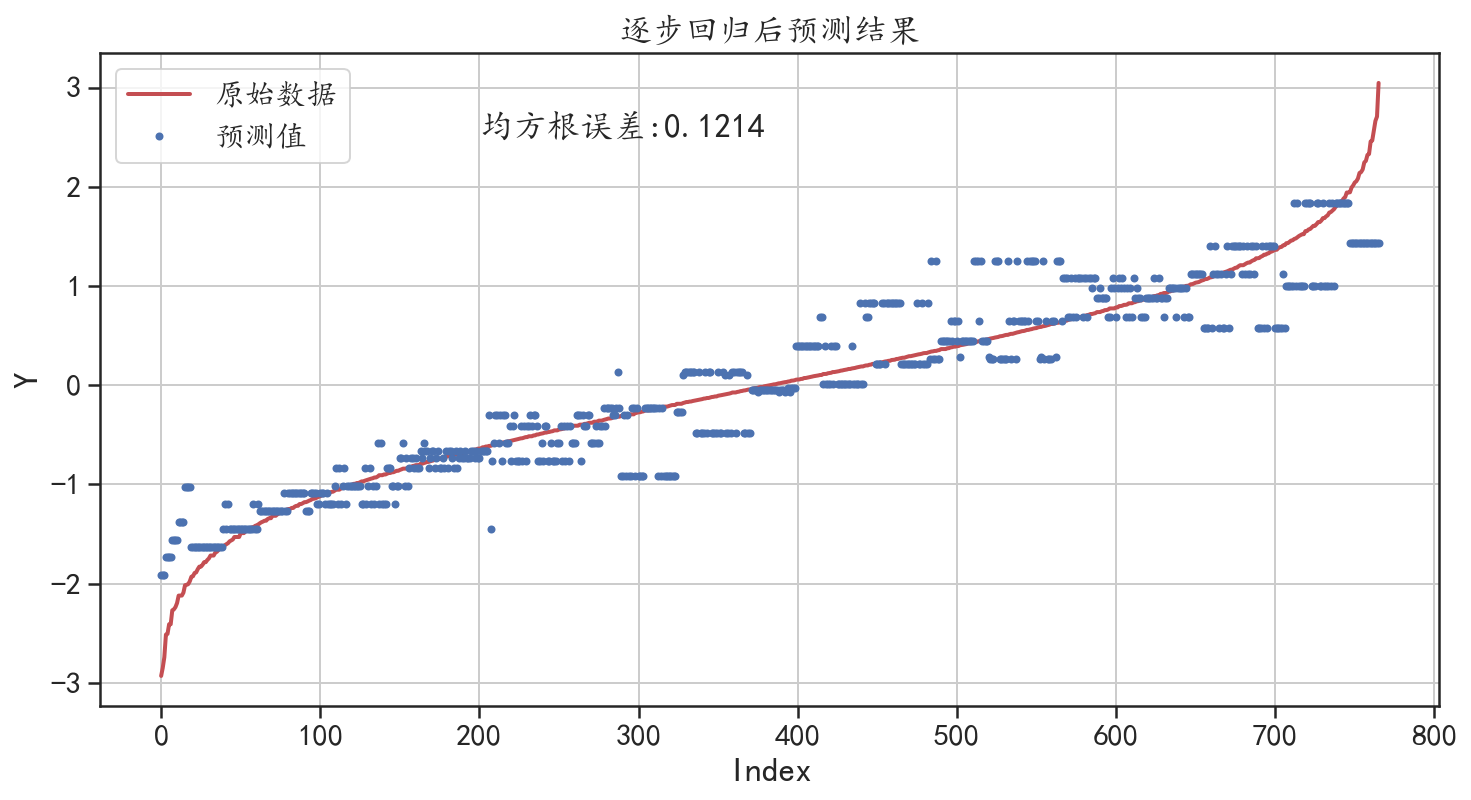

In [37]:
## 绘制回归的预测结果和原始数据的差异
Y_pre = lmstep.predict(Enb)
rmse = round(mean_squared_error(Enb.Y,Y_pre),4)
index = np.argsort(Enb.Y)
plt.figure(figsize=(12,6))
plt.plot(np.arange(Enb.shape[0]),Enb.Y[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(Enb.shape[0]),Y_pre[index],"bo",
         markersize=3,label = "预测值")
plt.text(200,2.5,s = "均方根误差:"+str(rmse))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("逐步回归后预测结果")
plt.show()

####  5.3.3 多变量自适应回归样条（Multivariate Adaptive Regression Splines, MARS）

它可以看成是逐步线性回归的推广

In [38]:
## 数据准备
X = np.array(Enb.iloc[:,0:-1])
y = np.array(Enb.Y)
## 拟合模型
model = Earth(max_terms = 20,max_degree = 3,feature_importance_type = "gcv")
marsfit = model.fit(X,y)
## 输出模型的结果
print(marsfit.summary())

Earth Model
-------------------------------------
Basis Function  Pruned  Coefficient  
-------------------------------------
(Intercept)     No      -35.5528     
x4              No      52.2683      
x6              No      0.27777      
x2              No      -16.5909     
x7*x6           No      -0.0519826   
x6*x4           No      -0.0509712   
x2*x6*x4        No      0.0852813    
x6*x6*x4        No      0.0661183    
x1              No      69.3403      
x7*x7*x6        No      0.0534038    
x2*x2           No      9.4173       
x2*x2*x2        No      -2.08044     
x4*x2*x2        No      0.974688     
x1*x2*x2        No      1.74892      
x1*x4           No      -35.0025     
x0*x1*x4        No      -14.167      
x0*x2           No      21.5804      
x0              No      3.04558      
x1*x7*x6        No      -0.0220651   
-------------------------------------
MSE: 0.0207, GCV: 0.0234, RSQ: 0.9790, GRSQ: 0.9763


In [39]:
print(marsfit.summary_feature_importances())

       gcv
x0     0.02   
x1     0.13   
x2     0.06   
x3     0.00   
x4     0.63   
x5     0.00   
x6     0.16   
x7     0.01   



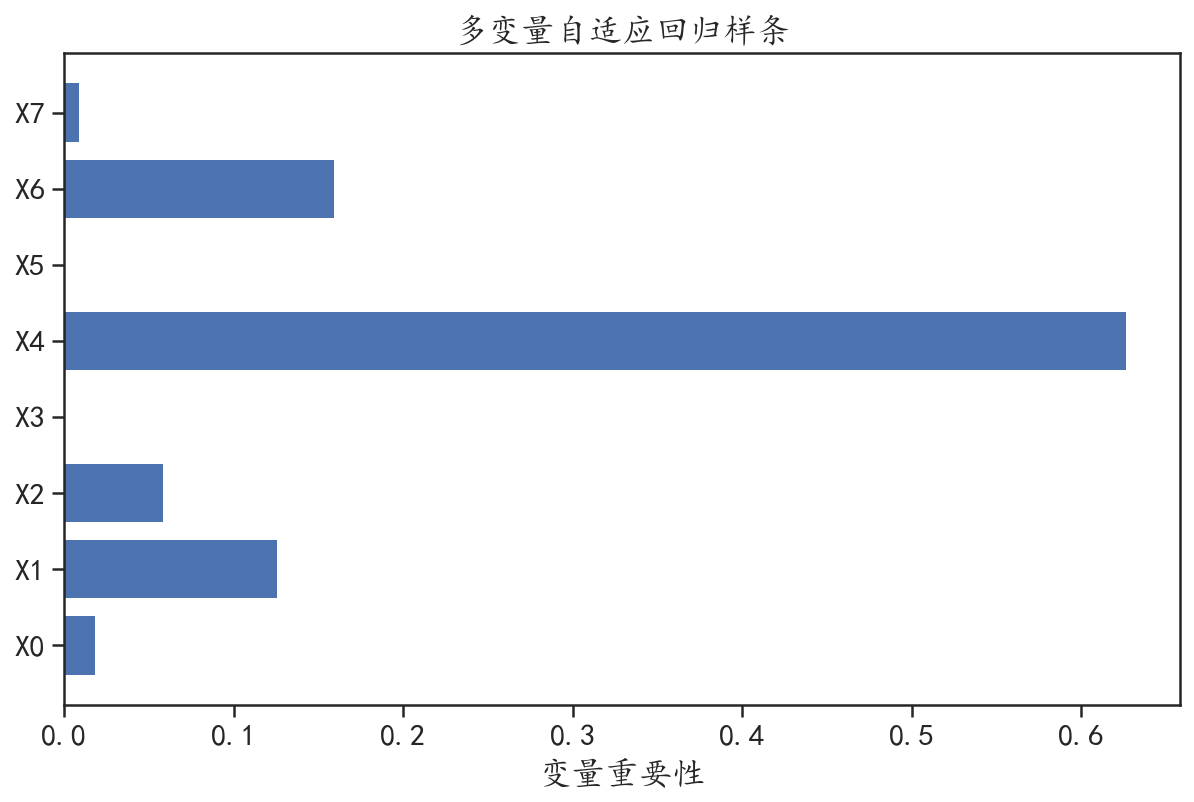

In [40]:
## 使用条形图可视化每个变量的重要性
plt.figure(figsize=(10,6))
plt.barh(y = ["X"+str(i) for i in range(8)],
         width=marsfit.feature_importances_)
plt.xlabel("变量重要性")
plt.title("多变量自适应回归样条")
plt.show()

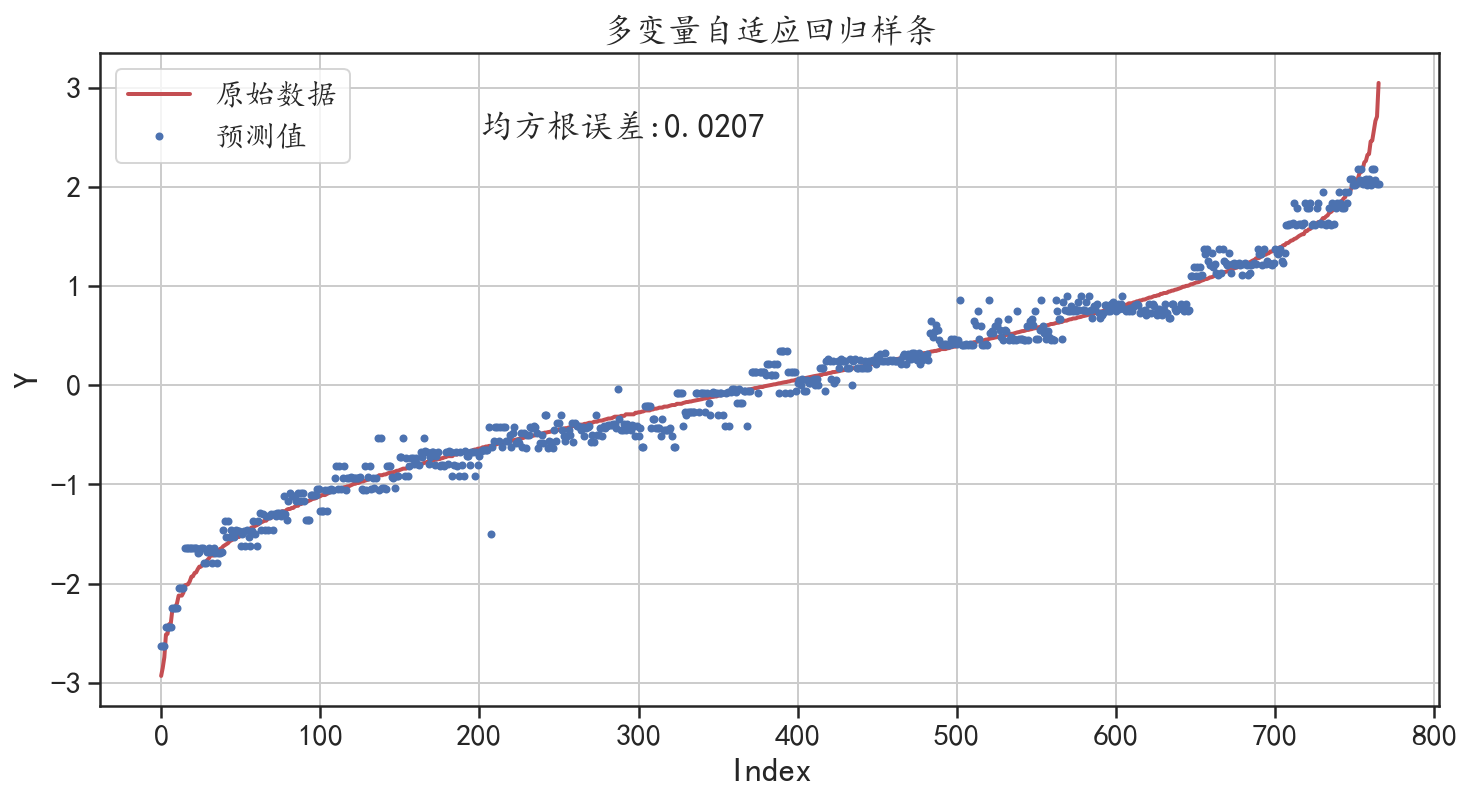

In [41]:
## 绘制回归的预测结果和原始数据的差异
Y_pre = marsfit.predict(X)
rmse = round(mean_squared_error(y,Y_pre),4)
index = np.argsort(y)
plt.figure(figsize=(12,6))
plt.plot(np.arange(len(y)),y[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(len(y)),Y_pre[index],"bo",
         markersize=3,label = "预测值")
plt.text(200,2.5,s = "均方根误差:"+str(rmse))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("多变量自适应回归样条")
plt.show()


### 5.4 正则化回归分析


In [3]:
## 数据准备，使用奥迪汽车的销量数据集
Audi = pd.read_csv("data/chap5/audi car price.csv")
print(Audi.head())

  model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0    A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4
1    A6  2016  16500    Automatic    36203   Diesel   20  64.2         2.0
2    A1  2016  11000       Manual    29946   Petrol   30  55.4         1.4
3    A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0
4    A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0


In [4]:
## 将几个类别特征进行one-hot编码
Audi = pd.get_dummies(Audi,["model","transmission","fuelType"])
Audi.head()

,year,price,mileage,tax,mpg,engineSize,model_ A1,model_ A2,model_ A3,model_ A4,...,model_ S8,model_ SQ5,model_ SQ7,model_ TT,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
0,2017,12500,15735,150,55.4,1.4,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,2016,16500,36203,20,64.2,2.0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,2016,11000,29946,30,55.4,1.4,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
3,2017,16800,25952,145,67.3,2.0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
4,2019,17300,1998,145,49.6,1.0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1


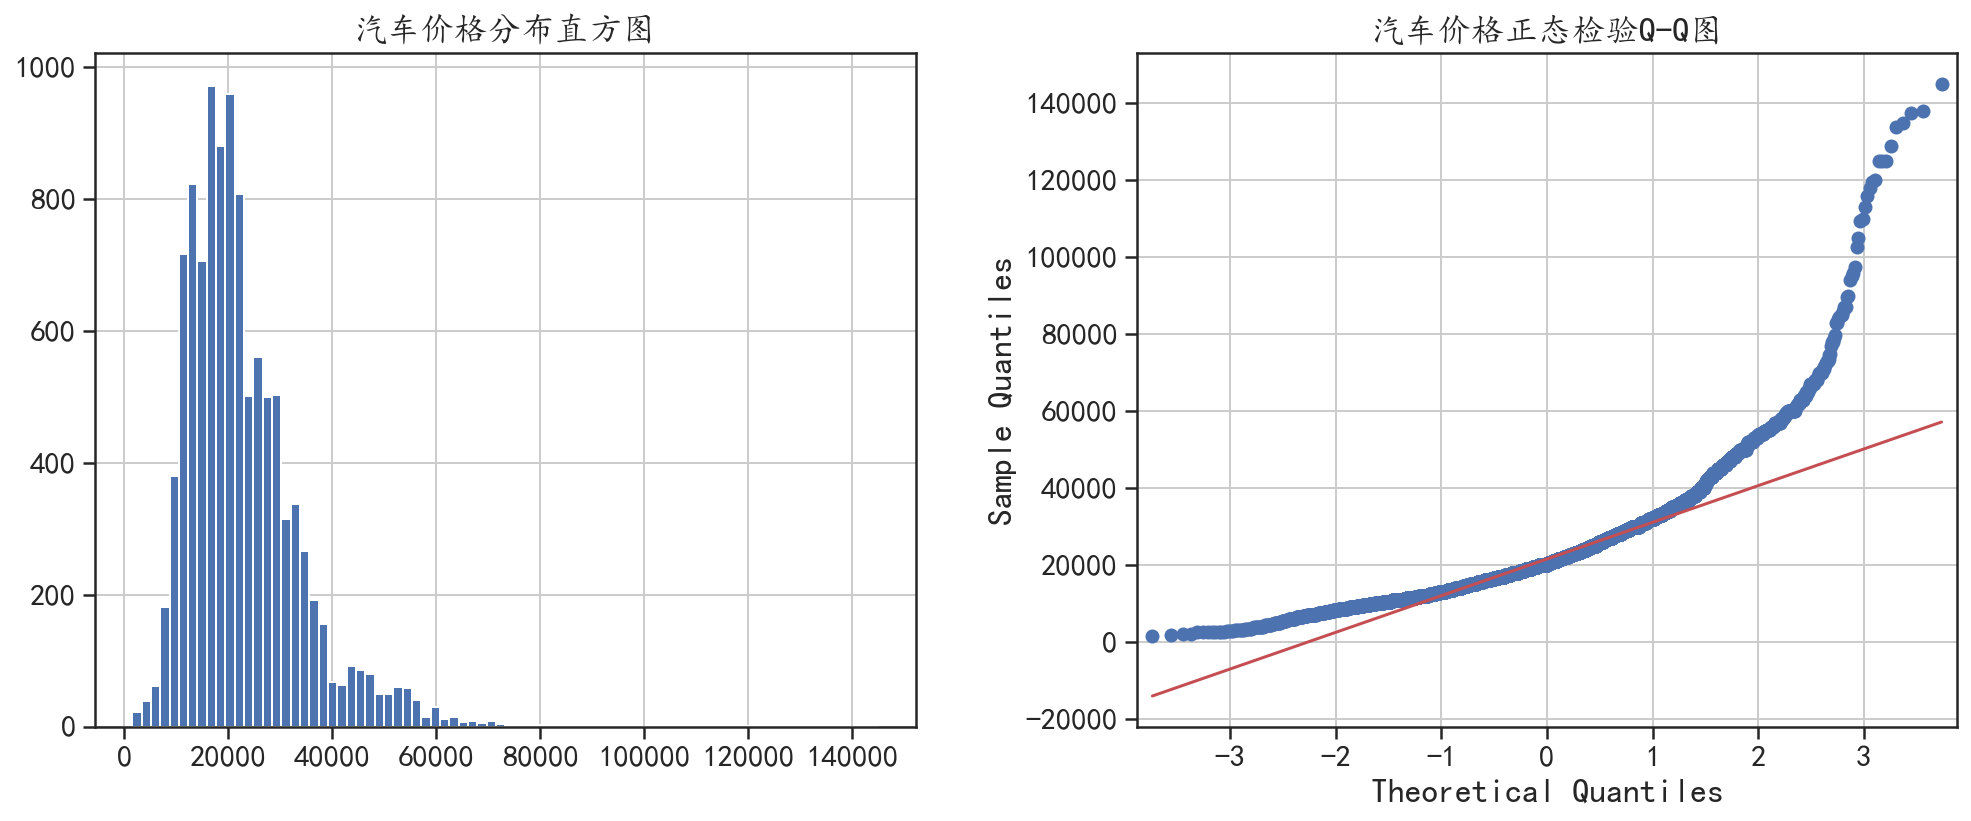

In [5]:
## 对因变量price的取值分布进行可视化，查看其是否为正态分布
fig = plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.hist(Audi.price,bins=80)
plt.grid()
plt.title("汽车价格分布直方图")
ax = fig.add_subplot(1,2,2)
sm.qqplot(Audi.price,line="q",ax = ax)
plt.grid()
plt.title("汽车价格正态检验Q-Q图")
plt.tight_layout()
plt.show()

## 可以发现因汽车价格的分布不是正态分布的，下面将其转化为正态分布，可以通过对数变换将其转化为正太分布

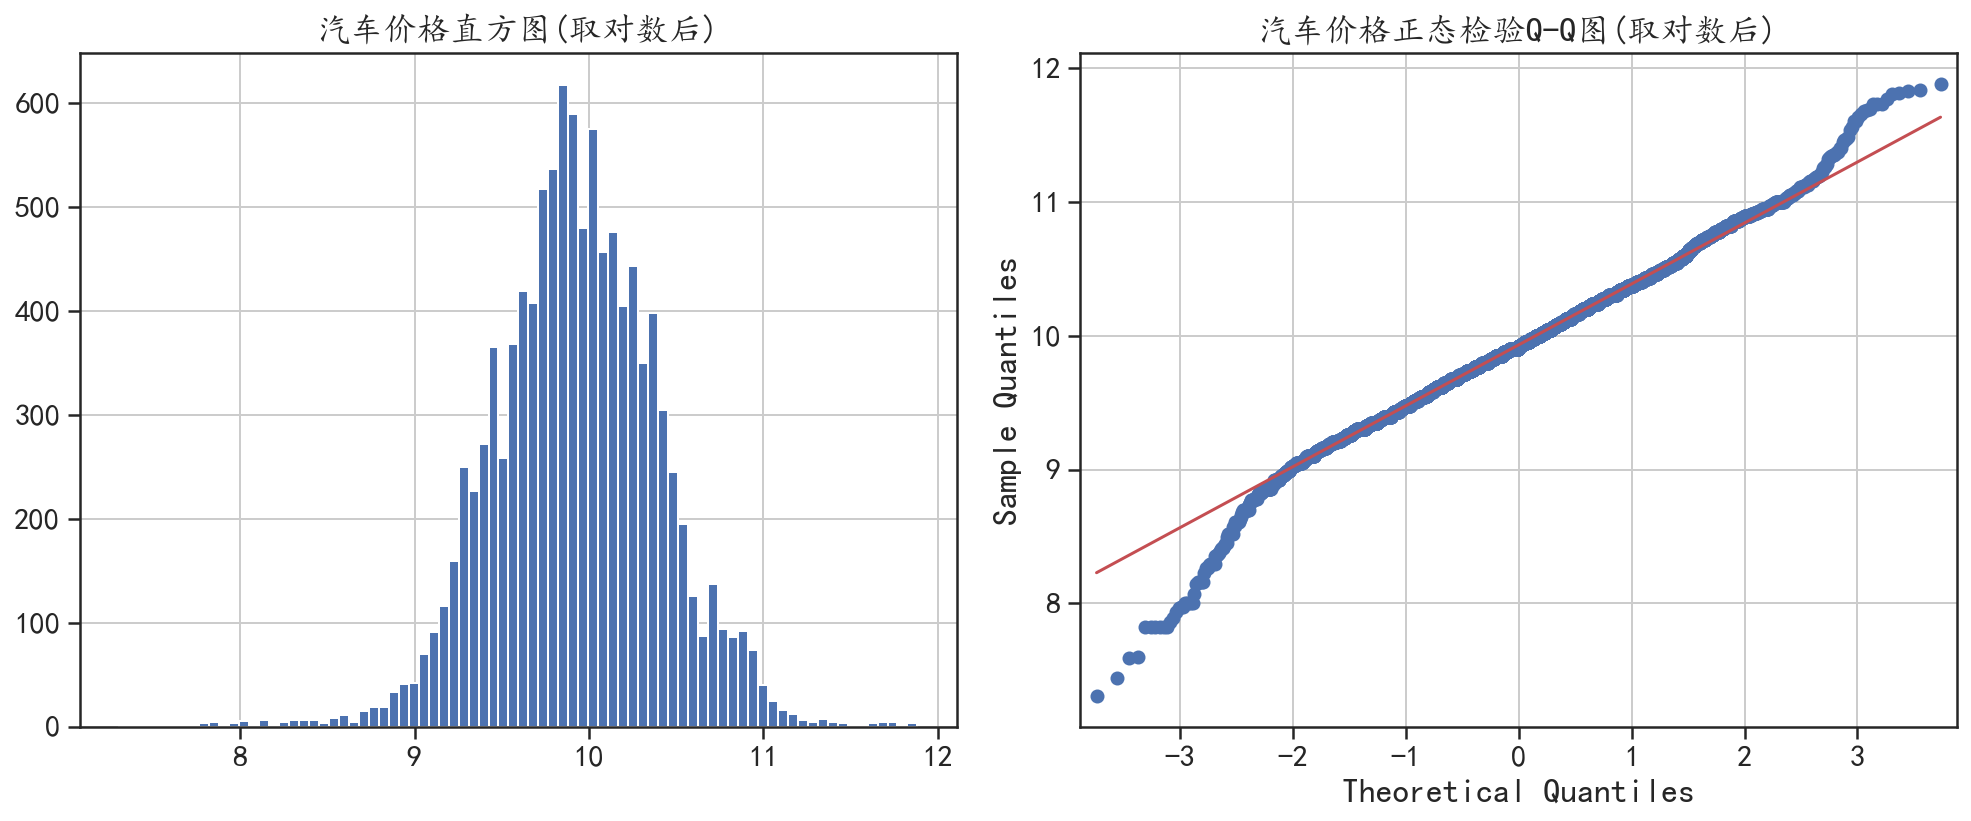

In [6]:
## 计算log(1+x)
Price = np.log1p(Audi.price)
## 可视化价格变换后的数据分布
fig = plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.hist(Price,bins=80)
plt.grid()
plt.title("汽车价格直方图(取对数后)")
ax = fig.add_subplot(1,2,2)
sm.qqplot(Price,line="q",ax = ax)
plt.grid()
plt.title("汽车价格正态检验Q-Q图(取对数后)")
plt.tight_layout()
plt.show()

## 可以发现汽车价格相对于原始的价格更接近于正态分布

In [7]:
## 获取数据的自变量
Audi_X = Audi.drop(labels=["price"],axis=1)
feature_name = Audi_X.columns
Audi_X = np.array(Audi_X)
## 将数据切分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(Audi_X, Price.values,
    test_size=0.25, random_state=42)
## 对数据的特征进行标准化预处理
stdscale = StandardScaler().fit(X_train)
X_train_s =  stdscale.transform(X_train)
X_test_s =  stdscale.transform(X_test)
print("训练数据:",X_train_s.shape)
print("测试数据:",X_test_s.shape)

训练数据: (8001, 37)
测试数据: (2667, 37)


In [8]:
feature_name

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_ A1', 'model_ A2',
       'model_ A3', 'model_ A4', 'model_ A5', 'model_ A6', 'model_ A7',
       'model_ A8', 'model_ Q2', 'model_ Q3', 'model_ Q5', 'model_ Q7',
       'model_ Q8', 'model_ R8', 'model_ RS3', 'model_ RS4', 'model_ RS5',
       'model_ RS6', 'model_ RS7', 'model_ S3', 'model_ S4', 'model_ S5',
       'model_ S8', 'model_ SQ5', 'model_ SQ7', 'model_ TT',
       'transmission_Automatic', 'transmission_Manual',
       'transmission_Semi-Auto', 'fuelType_Diesel', 'fuelType_Hybrid',
       'fuelType_Petrol'],
      dtype='object')

####  5.3.1 Ridge回归分析

In [48]:
## 定义回归函数
def ridge_regression(X_train, y_train, X_test, y_test, alpha):
    ## X_train, X_test, y_train, y_test:输入的训练数据和测试数据
    # Ridge回归模型
    model = Ridge(alpha=alpha, max_iter=1e5)
    model.fit(X_train,y_train)      # 拟合模型
    y_pred = model.predict(X_test)  # 预测
    ## 输出模型的测试结果
    ret = [alpha]                      # 惩罚参数alpha
    ret.append(r2_score(y_test,y_pred)) # R^2
    ret.append(mean_absolute_error(y_test,y_pred)) # 绝对值误差
    ret.extend(model.coef_)      # Ridge回归模型的系数
    return ret

# ridge_regression(X_train_s, y_train,X_test_s, y_test,0.01)

In [49]:
## 使用ridge_regression函数，利用不同的参数alpha进行回归分析
# 定义alpha的取值范围
alpha_ridge = [0.00001,0.00005,0.0001,0.0005,0.001,0.005,0.01,0.05,
               0.1,0.5,1,5,10,50,100,500,1000,5000]

# 初始化数据表用来保存系数和得分
col = [["alpha","r2_score","mae"],list(feature_name.values)]
col = [val for sublist in col for val in sublist]   # 数据表列名
ind = ["alpha_%.g"%alp for alp in alpha_ridge]     # 数据表索引
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col)

#根据alpha的值进行Ridge回归
for ii,alpha in enumerate(alpha_ridge):
    coef_matrix_ridge.iloc[ii,]=ridge_regression(X_train_s, y_train,
                                                 X_test_s, y_test,alpha)

coef_matrix_ridge.sample(5)

,alpha,r2_score,mae,year,mileage,tax,mpg,engineSize,model_ A1,model_ A2,...,model_ S8,model_ SQ5,model_ SQ7,model_ TT,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
alpha_0.001,0.001,0.93566,0.0926323,0.217421,-0.115223,-0.00767718,-0.0508405,0.106363,-0.074139,-0.0011728,...,0.00287004,0.0113013,0.0118061,0.00292811,0.0136837,-0.0307258,0.0193728,-0.0100215,0.0303846,0.00676636
alpha_1e+02,100,0.935734,0.0924619,0.212925,-0.116459,-0.00706462,-0.053124,0.103934,-0.0730729,-0.00143024,...,0.00288224,0.0110874,0.0117109,0.00277992,0.0139899,-0.0314086,0.0198013,-0.00903677,0.0309769,0.00571784
alpha_0.0001,0.0001,0.93566,0.0926323,0.217421,-0.115223,-0.00767718,-0.0508405,0.106363,-0.0741391,-0.0011728,...,0.00287004,0.0113013,0.0118061,0.00292811,0.0136837,-0.0307258,0.0193728,-0.0100215,0.0303846,0.00676636
alpha_1e+01,10,0.935674,0.092612,0.21695,-0.115359,-0.00762182,-0.0510944,0.106104,-0.0740298,-0.00120005,...,0.00287219,0.0112797,0.0117971,0.00291281,0.0137143,-0.0307959,0.0194175,-0.00991564,0.0304549,0.00665293
alpha_0.05,0.05,0.93566,0.0926322,0.217419,-0.115224,-0.00767691,-0.0508418,0.106362,-0.0741385,-0.00117294,...,0.00287005,0.0113012,0.0118061,0.00292803,0.0136838,-0.0307262,0.019373,-0.010021,0.030385,0.0067658


In [50]:
## 将回归结果根据绝对值误差的大小进行排序
ridge_result = coef_matrix_ridge.iloc[:,0:3]
print(ridge_result.sort_values("mae",ascending=True).head())

## 可以发现当alpha=100时，回归模型的预测效果最好

            alpha  r2_score        mae
alpha_1e+02   100  0.935734  0.0924619
alpha_5e+01    50  0.935715  0.0925373
alpha_5e+02   500  0.934902  0.0925817
alpha_1e+01    10  0.935674   0.092612
alpha_5         5  0.935667  0.0926221


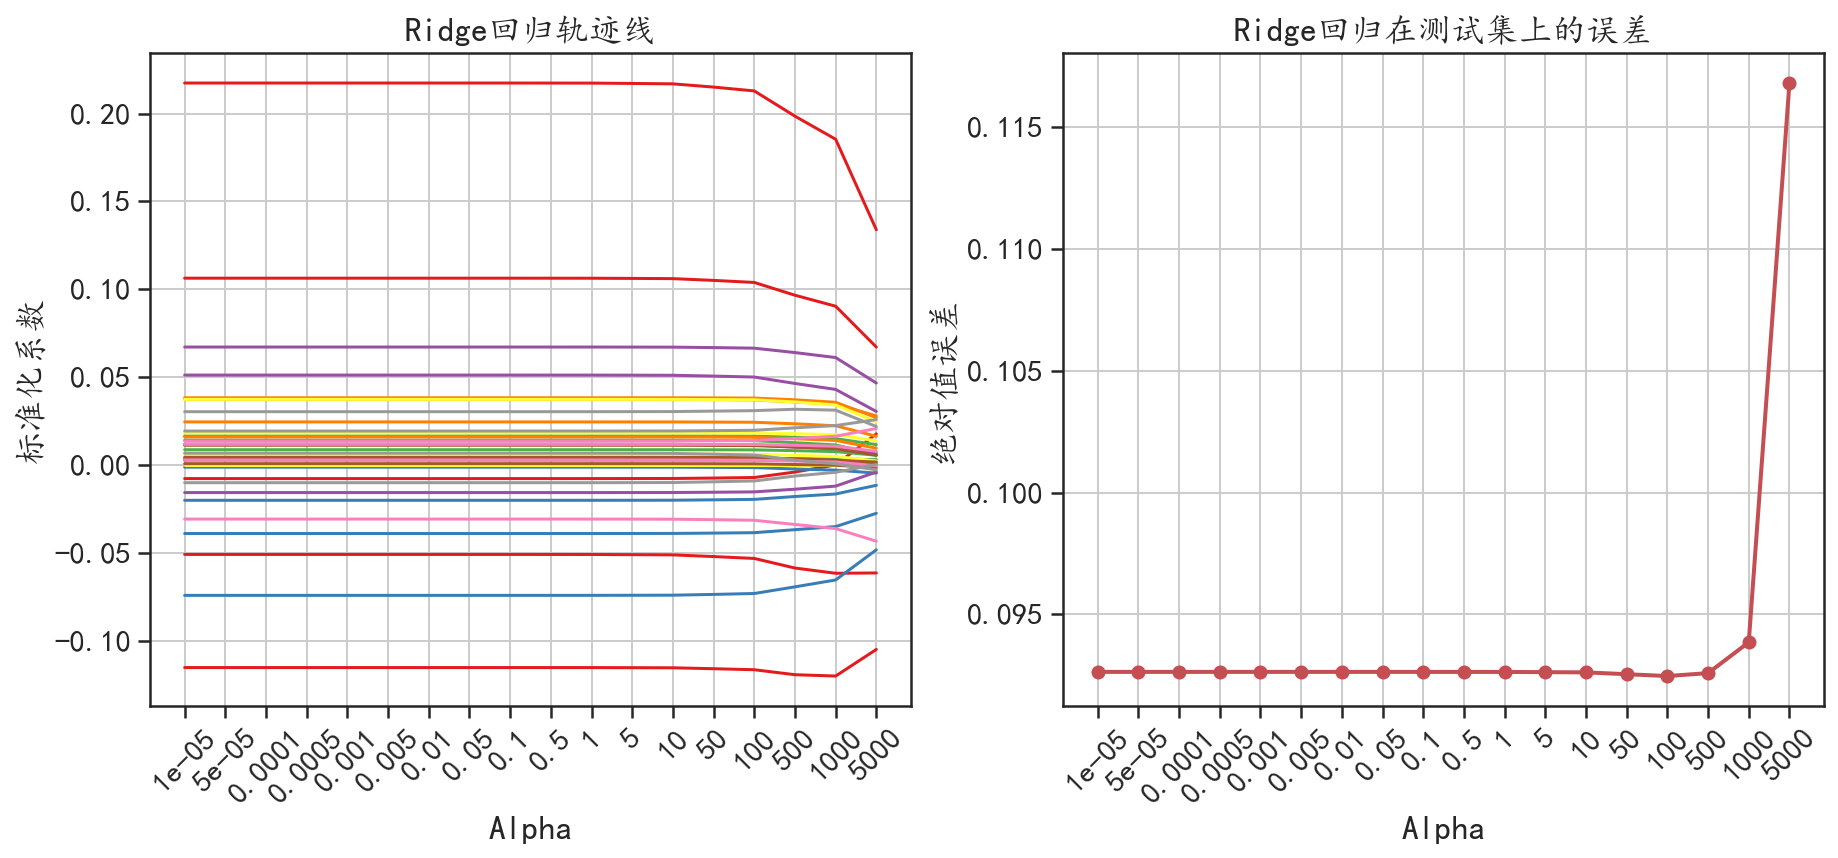

In [51]:
## 可视化不同alpha取值下每个自变量的轨迹线
feature_number = len(feature_name)  ## 特征的数量
x = range(len(alpha_ridge))
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
for ii in np.arange(feature_number):
    plt.plot(x,coef_matrix_ridge[feature_name[ii]],
             color = plt.cm.Set1(ii / feature_number),label = ii)
## 设置X坐标轴的标签
plt.xticks(x,alpha_ridge,rotation=45)
plt.xlabel("Alpha")
plt.ylabel("标准化系数")
plt.title("Ridge回归轨迹线")
plt.grid()
    
## 在测试集上绝对值误差的变化情况
plt.subplot(1,2,2)
plt.plot(x,coef_matrix_ridge["mae"],"r-o",linewidth = 2)
## 设置X坐标轴的标签
plt.xticks(x,alpha_ridge,rotation=45)
plt.xlabel("Alpha")
plt.ylabel("绝对值误差")
plt.title("Ridge回归在测试集上的误差")
plt.grid()
plt.show()


####  5.3.2 Lasso回归分析

In [52]:
## 定义回归函数
def lasso_regression(X_train, y_train, X_test, y_test, alpha):
    ## X_train, X_test, y_train, y_test:输入的训练数据和测试数据
    # Lasso回归模型
    model = Lasso(alpha=alpha, max_iter=1e5)
    model.fit(X_train,y_train)      # 拟合模型
    y_pred = model.predict(X_test)  # 预测
    ## 输出模型的测试结果
    ret = [alpha]                      # 惩罚参数alpha
    ret.append(r2_score(y_test,y_pred)) # R^2
    ret.append(mean_absolute_error(y_test,y_pred)) # 绝对值误差
    ret.extend(model.coef_)      # Lasso回归模型的系数
    return ret

## lasso_regression(X_train_s, y_train,X_test_s, y_test,0.01)

In [53]:
## 使用lasso_regression函数，利用不同的参数alpha进行回归分析
# 定义alpha的取值范围
alpha_lasso = [0.00001,0.00005,0.0001,0.0005,0.001,0.005,0.01,0.05,
               0.1,0.5,1,5,10,50,100,500,1000,5000]

# 初始化数据表用来保存系数和得分
col = [["alpha","r2_score","mae"],list(feature_name.values)]
col = [val for sublist in col for val in sublist]   # 数据表列名
ind = ['alpha_%.g'%alp for alp in alpha_lasso]     # 数据表索引
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col)

#根据alpha的值进行Lasso回归
for ii,alpha in enumerate(alpha_lasso):
    coef_matrix_lasso.iloc[ii,]=lasso_regression(X_train_s, y_train,
                                                 X_test_s, y_test,alpha)

coef_matrix_lasso.sample(5)

,alpha,r2_score,mae,year,mileage,tax,mpg,engineSize,model_ A1,model_ A2,...,model_ S8,model_ SQ5,model_ SQ7,model_ TT,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Petrol
alpha_5,5,-3.12193e-05,0.372899,0,-0,0,-0,0,-0,-0,...,0,0,0,-0,0,-0,0,-0,0,0
alpha_0.05,0.05,0.870596,0.128771,0.206069,-0.0855,0,-0.0573362,0.148632,-0.0122501,-0,...,-0,0,0,0,0,-0.0424611,0,-0,0,-0
alpha_0.0005,0.0005,0.935729,0.0926053,0.217716,-0.114808,-0.00542947,-0.050059,0.108049,-0.0838433,-0.00101234,...,0.00136854,0.00942028,0.0103396,-0.00240592,0,-0.0464038,0.00399141,-0.0159171,0.029025,0
alpha_0.005,0.005,0.932931,0.0944798,0.21624,-0.11203,0,-0.0549895,0.120213,-0.0685508,-0,...,0,0.0039084,0.00456261,-0,0,-0.0484792,5.56292e-05,-0.00631364,0.0277011,0
alpha_0.0001,0.0001,0.935727,0.0926101,0.217482,-0.115142,-0.00722162,-0.050667,0.106706,-0.0853477,-0.00145132,...,0.00194774,0.00994292,0.0108912,-0.00293817,0,-0.0462353,0.00440561,-0.0166235,0.0295249,0


In [54]:
## 将回归结果根据绝对值误差的大小进行排序
lasso_result = coef_matrix_lasso.iloc[:,0:3]
## 计算不同alpha取值下有多少个自变量的系数为0
lasso_result["var_zreo_num"] = (coef_matrix_lasso.iloc[:,3:40] == 0).astype(int).sum(axis = 1)
print(lasso_result.sort_values("mae",ascending=True).head(8))

## 可以发现当alpha=0.0005时，回归模型的预测效果最好,并且有5个自变量的回归系数等于0

               alpha  r2_score        mae  var_zreo_num
alpha_0.0005  0.0005  0.935729  0.0926053             5
alpha_0.0001  0.0001  0.935727  0.0926101             4
alpha_5e-05    5e-05  0.935721  0.0926145             4
alpha_1e-05    1e-05  0.935716  0.0926183             4
alpha_0.001    0.001  0.935635  0.0926867             5
alpha_0.005    0.005  0.932931  0.0944798            12
alpha_0.01      0.01  0.926967  0.0978147            19
alpha_0.05      0.05  0.870596   0.128771            30


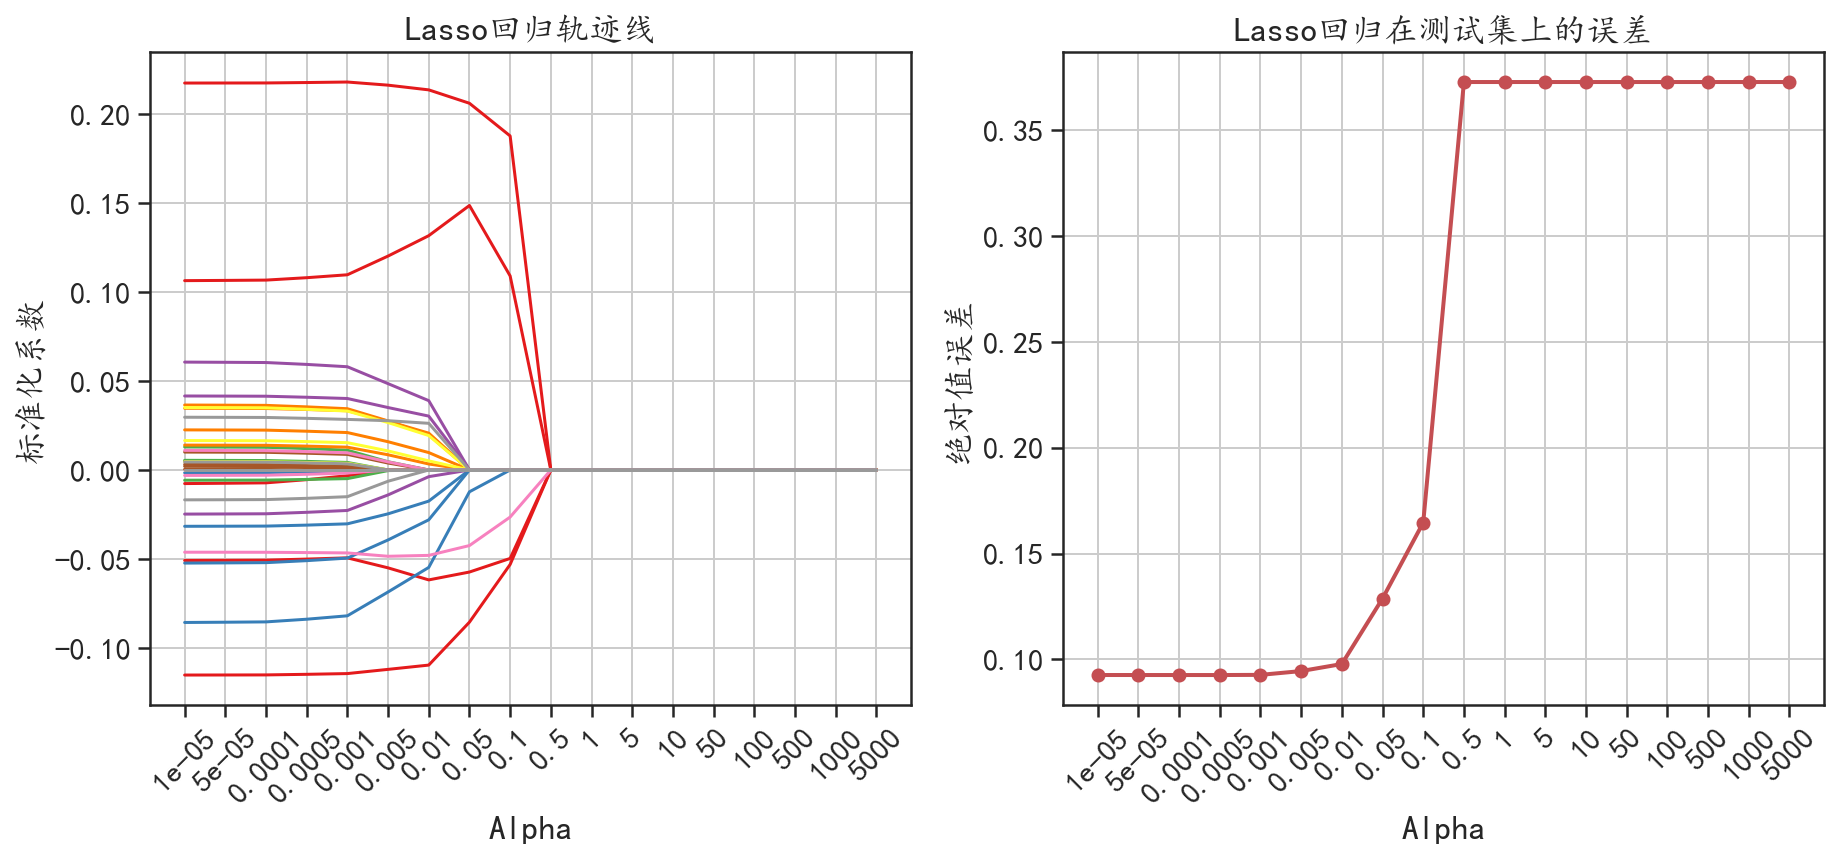

In [55]:
## 可视化不同alpha取值下每个自变量的轨迹线
feature_number = len(feature_name)  ## 特征的数量
x = range(len(alpha_lasso))
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
for ii in np.arange(feature_number):
    plt.plot(x,coef_matrix_lasso[feature_name[ii]],
             color = plt.cm.Set1(ii / feature_number),label = ii)
## 设置X坐标轴的标签
plt.xticks(x,alpha_ridge,rotation=45)
plt.xlabel("Alpha")
plt.ylabel("标准化系数")
plt.title("Lasso回归轨迹线")
plt.grid()
    
## 在测试集上绝对值误差的变化情况
plt.subplot(1,2,2)
plt.plot(x,coef_matrix_lasso["mae"],"r-o",linewidth = 2)
## 设置X坐标轴的标签
plt.xticks(x,alpha_ridge,rotation=45)
plt.xlabel("Alpha")
plt.ylabel("绝对值误差")
plt.title("Lasso回归在测试集上的误差")
plt.grid()
plt.show()


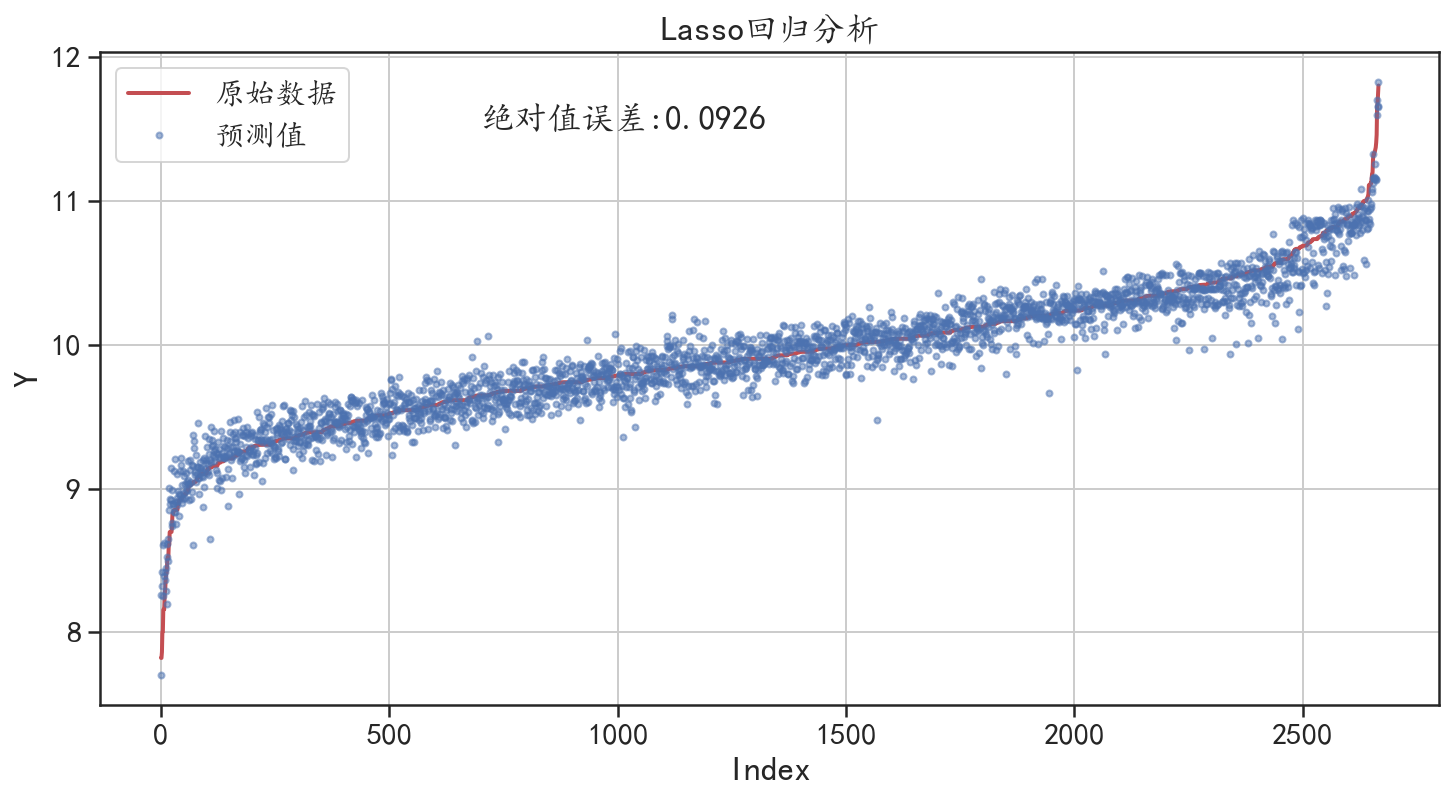

In [56]:
## 可视化Lasso回归模型对测试集的预测效果
lassoreg = Lasso(alpha=0.0005,max_iter=1e5)
lassoreg.fit(X_train_s,y_train)
Y_pre = lassoreg.predict(X_test_s)
## 计算在测试集上的预测误差
mae = round(mean_absolute_error(y_test,Y_pre),4)
index = np.argsort(y_test)
plt.figure(figsize=(12,6))
plt.plot(np.arange(len(y_test)),y_test[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(len(y_test)),Y_pre[index],"bo",
         markersize=3,alpha = 0.5,label = "预测值")
plt.text(700,11.5,s = "绝对值误差:"+str(mae))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("Lasso回归分析")
plt.show()

#### 5.4.3 弹性网络（Elastic Net）

In [9]:
## 使用交叉验证的方式进行参数alpha选择
l1_ratio = [0.05,0.1,0.2,0.3,0.4,0.5, 0.7, 0.9, 0.95, 0.99, 1]
alphas = [0.00001,0.00005,0.0001,0.0005,0.001,0.005,0.01,0.05,
          0.1,0.5,1,5,10,50,100,500,1000,5000]
model = ElasticNetCV(l1_ratio = l1_ratio,  # 调整l1和l2惩罚的比例
                     alphas = alphas, cv=5,
                     random_state = 12).fit(X_train_s, y_train)
print("效果最好的参数alpha:",model.alpha_)
print("效果最好的参数l1_ratio:",model.l1_ratio_)
print("特征的系数为:\n",model.coef_)

效果最好的参数alpha: 1e-05
效果最好的参数l1_ratio: 0.05
特征的系数为:
 [ 2.17418576e-01 -1.15223941e-01 -7.67438562e-03 -5.08382571e-02
  1.06363416e-01 -1.00382963e-01 -2.05286583e-03 -6.93050964e-02
 -4.63619852e-02 -1.78645309e-02 -5.64932377e-03  3.68748090e-04
  8.33378995e-03 -3.64006255e-02 -1.50314009e-02  2.93969346e-02
  5.23687356e-02  3.11824825e-02  3.42728429e-02  1.14553054e-02
  1.99992480e-02  1.43544414e-02  3.22113371e-02  0.00000000e+00
  2.75161355e-03  1.52020693e-03 -6.36796523e-05  1.10879894e-03
  8.51805786e-03  1.00449342e-02 -1.06672104e-02  9.93704101e-03
 -3.49605448e-02  1.53033206e-02 -1.73606433e-02  2.95963645e-02
 -5.69779094e-04]


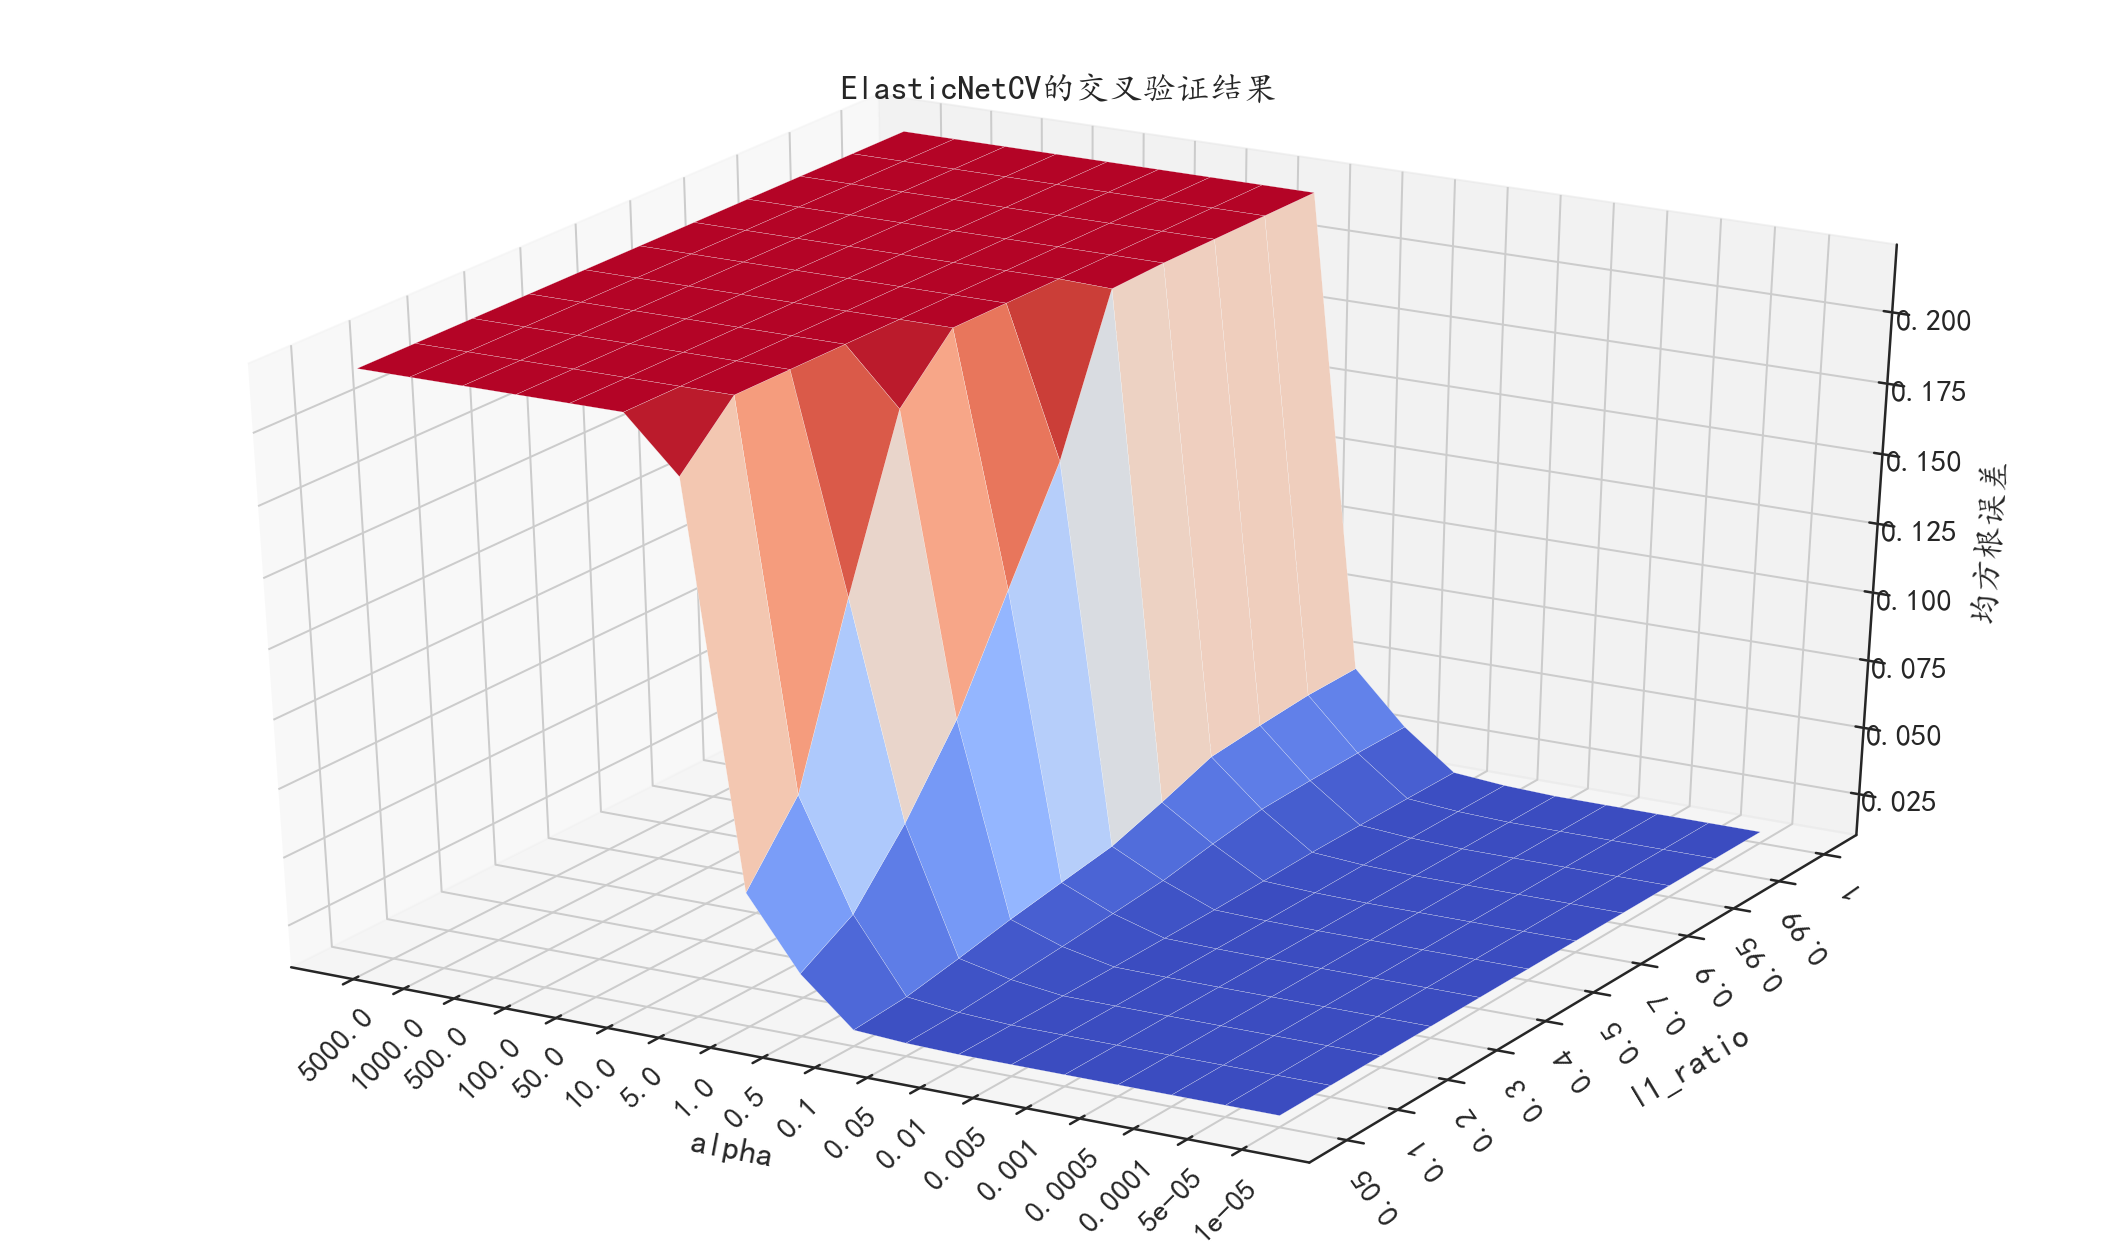

In [10]:
## 使用3D曲面图可视化交叉验证的平均均方根误差
mean_mse = model.mse_path_.mean(axis = 2)
alp = model.alphas_
l1_r = model.l1_ratio
## 数据准备
x, y = np.meshgrid(range(len(alp)),range(len(l1_r)))
## 可视化
fig = plt.figure(figsize=(15,9))
ax1 = fig.add_subplot(111, projection="3d")
surf = ax1.plot_surface(x,y,mean_mse,cmap=plt.cm.coolwarm,
                        linewidth=0.1)
plt.xticks(range(len(alp)),alp,rotation=45)
plt.yticks(range(len(l1_r)),l1_r,rotation=125)
ax1.set_zlabel("均方根误差",labelpad=10)
ax1.set_xlabel("alpha",labelpad=20)
ax1.set_ylabel("l1_ratio",labelpad=20)
ax1.set_title("ElasticNetCV的交叉验证结果")
plt.tight_layout()
plt.show()

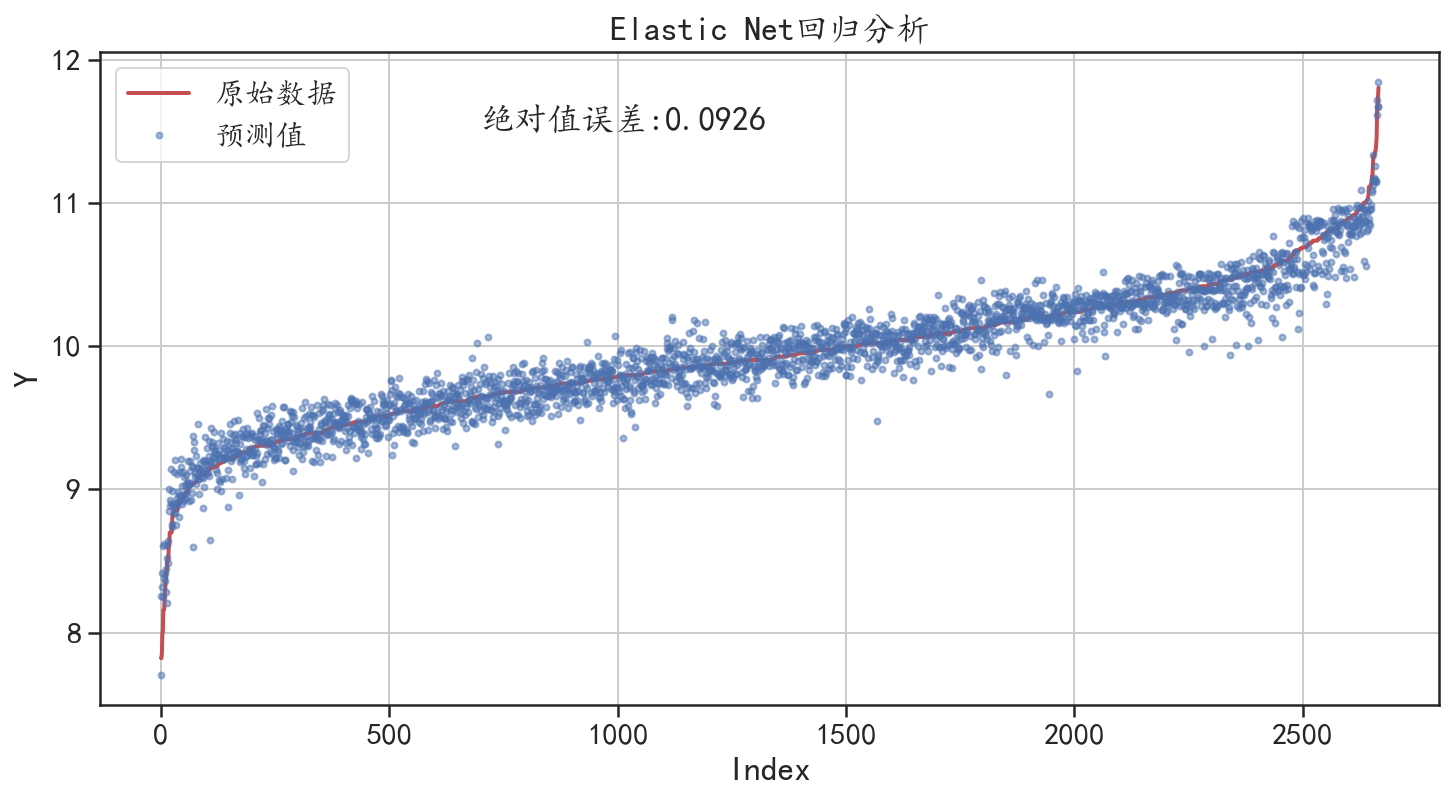

In [11]:
## 使用交叉验证训练得到的模型对测试集进行预测
Y_pre = model.predict(X_test_s)
## 计算在测试集上的预测误差
mae = round(mean_absolute_error(y_test,Y_pre),4)
index = np.argsort(y_test)
plt.figure(figsize=(12,6))
plt.plot(np.arange(len(y_test)),y_test[index],"r",
         linewidth=2, label = "原始数据")
plt.plot(np.arange(len(y_test)),Y_pre[index],"bo",
         markersize=3,alpha = 0.5,label = "预测值")
plt.text(700,11.5,s = "绝对值误差:"+str(mae))
plt.legend()
plt.grid()
plt.xlabel("Index")
plt.ylabel("Y")
plt.title("Elastic Net回归分析")
plt.show()


### 5.5 Logistic回归分析

In [12]:
## 读取声音特征数据
voice = pd.read_csv("data/chap5/voice.csv")
voice.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [13]:
## 计算每类数据的样本数量
voice.label.value_counts()

male      1584
female    1584
Name: label, dtype: int64

In [14]:
## 数据探索和可视化
varname = voice.columns.values[0:-1]  # 数据的特征名称
voice_X = voice.drop(["label"],axis = 1).values
voice_Y = voice.label.values
## 对每个变量进行标准化处理
stds = StandardScaler().fit(voice_X)
voice_X_s =  stds.transform(voice_X)
## 将类别标签使用0和1进行编码
voice_Y01 = np.where(voice_Y == "female",0,1)
print(voice_X_s.shape)
print(np.unique(voice_Y01,return_counts = True))

(3168, 20)
(array([0, 1]), array([1584, 1584]))


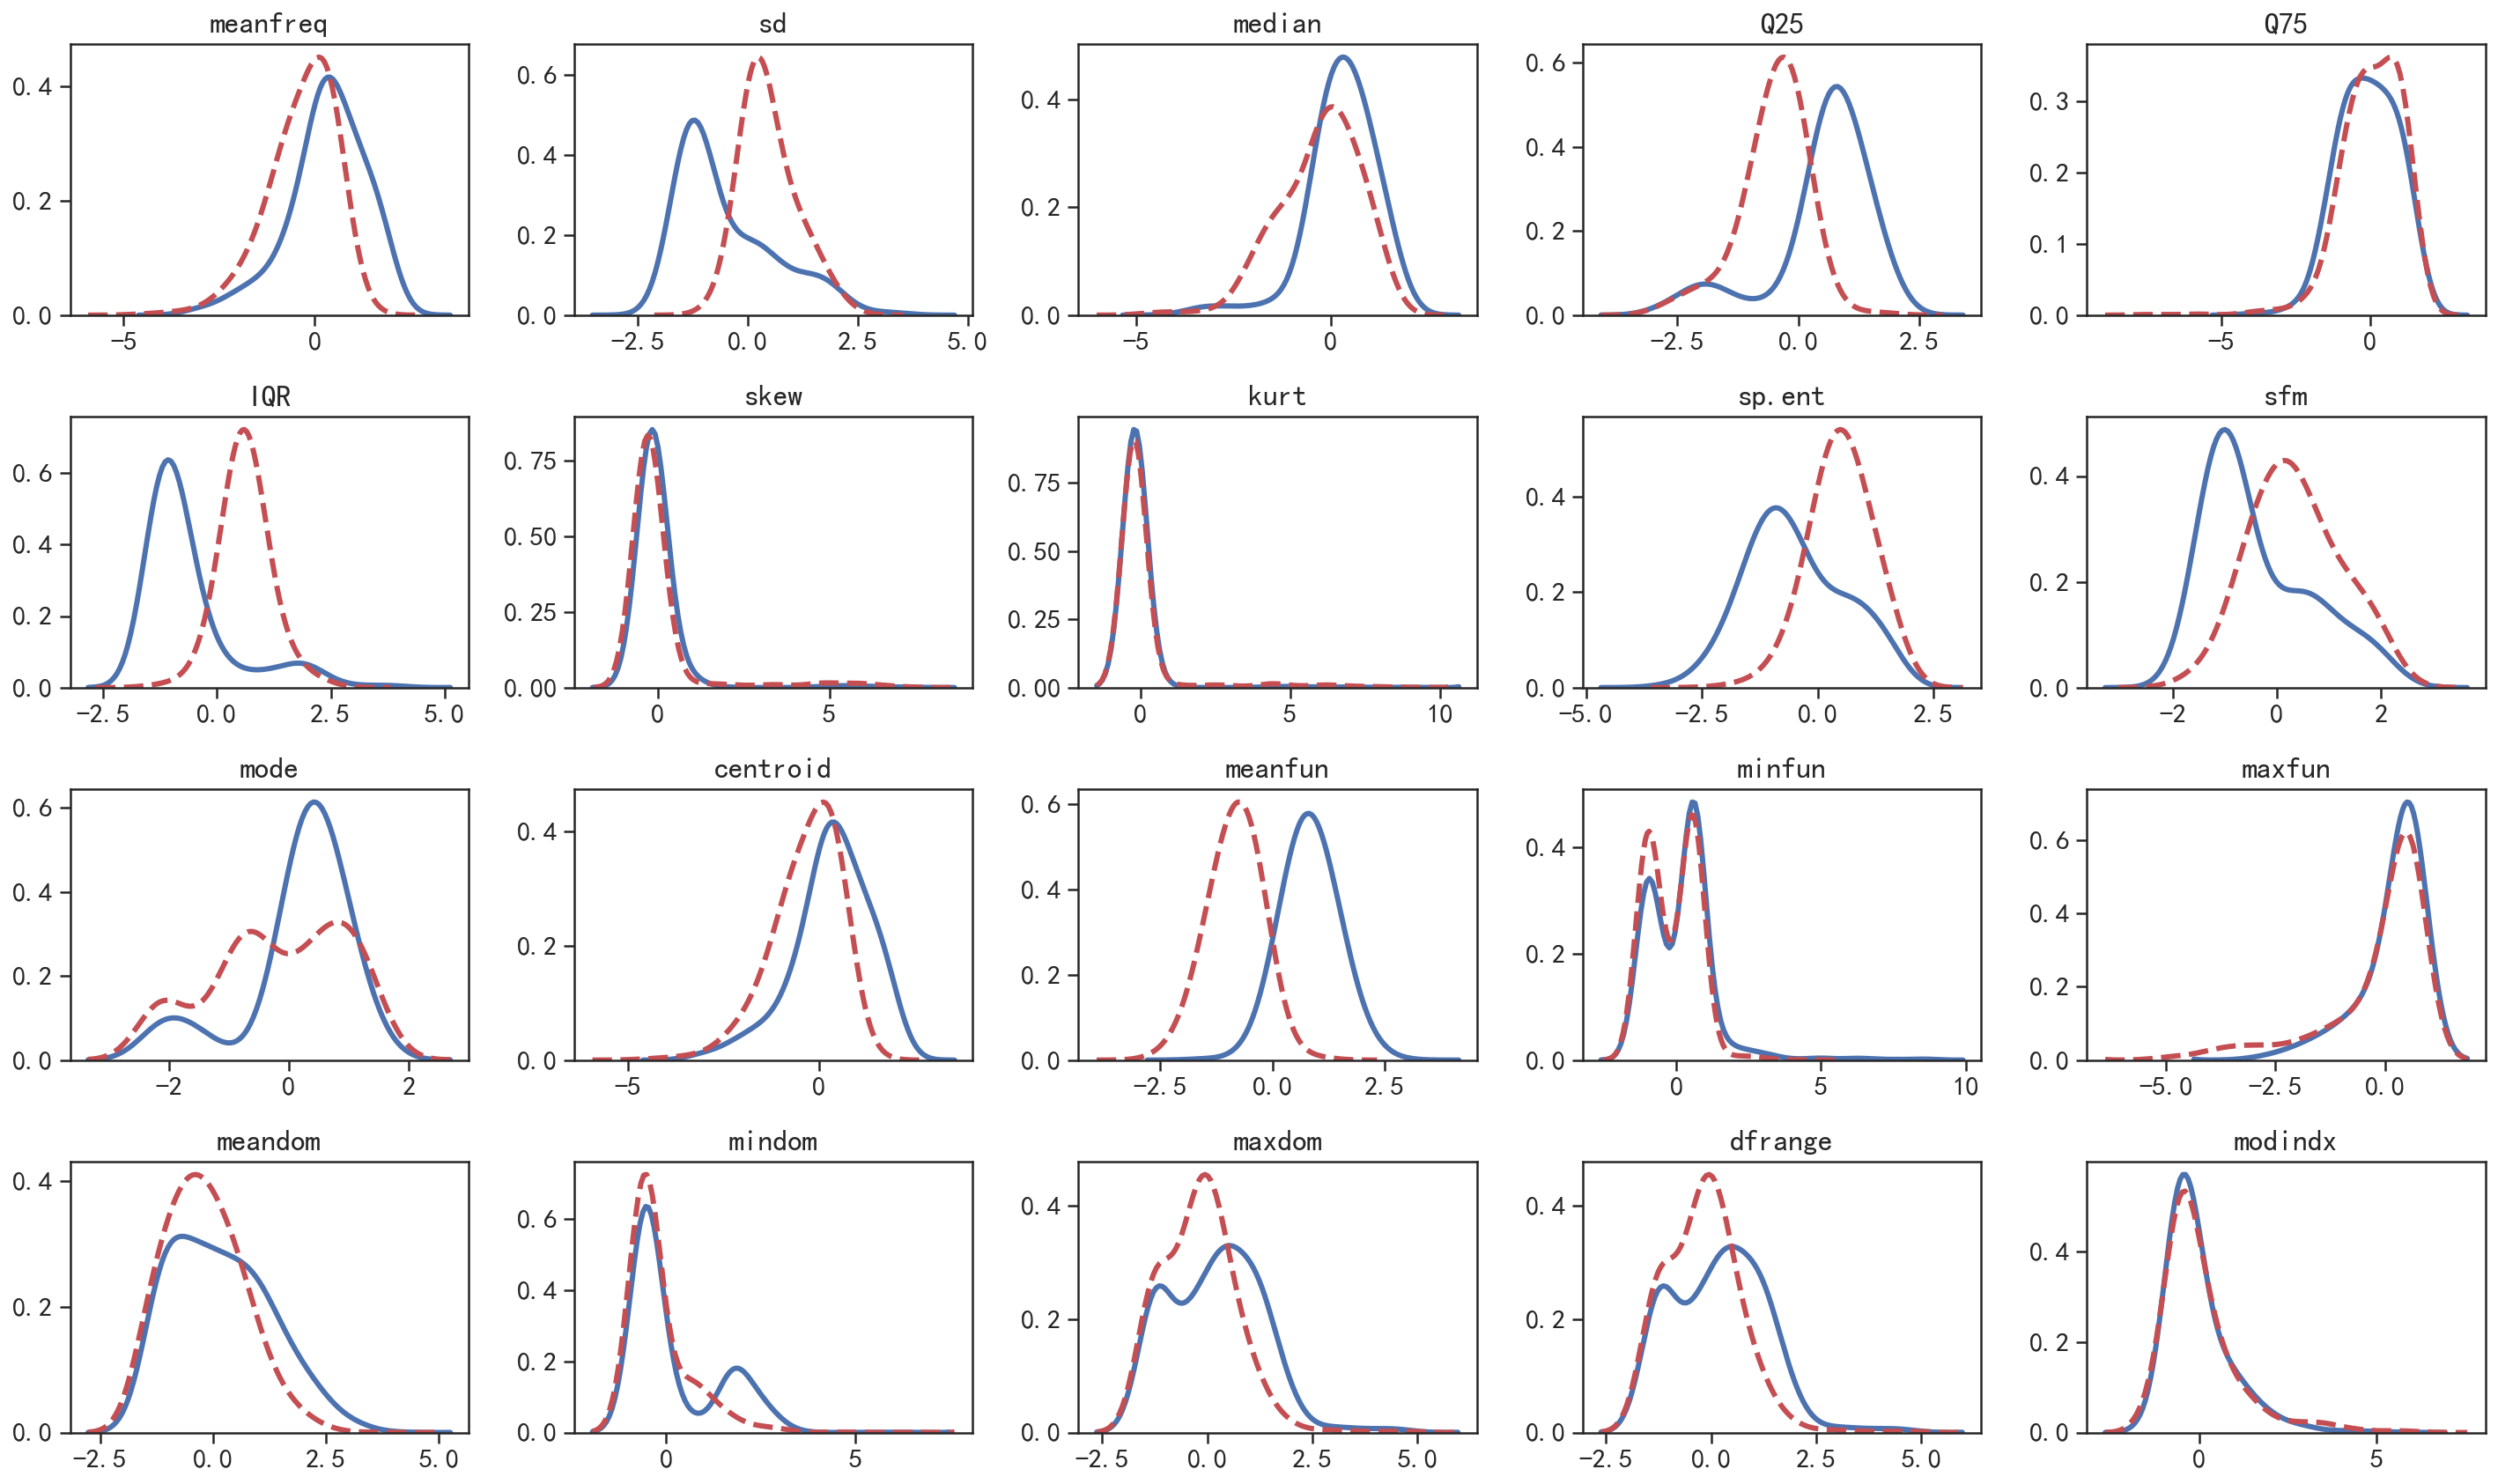

In [15]:
## 可视化不同类别下每个特征的数据分布
plt.figure(figsize=(20,12))
for ii,name in enumerate(varname):
    plt.subplot(4,5,ii+1)
    plotdata = voice_X_s[:,ii]  ## 对应的特征
    sns.distplot(plotdata[voice_Y == "female"],hist=False,
                 kde_kws={"color": "b", "lw": 3,"bw":0.4})
    sns.distplot(plotdata[voice_Y == "male"],hist=False,
                 kde_kws={"color": "r", "lw": 3,"bw":0.4,"ls":"--"})
    plt.title(name)
plt.tight_layout()
plt.show()

## 可以发现有些特征对数据类别的区分较有利

In [16]:
## 使用逻辑回归进行预测和分类

## 数据切分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(voice_X_s, voice_Y01,
    test_size=0.25, random_state=42)
print("训练数据:",X_train.shape)
print("测试数据:",X_test.shape)

训练数据: (2376, 20)
测试数据: (792, 20)


In [17]:
## 使用交叉验证的逻辑回归模型进行参数选择
cs = [0.00001,0.00005,0.0001,0.0005,0.001,0.005,0.01,0.05,
      0.1,0.5,1,5,10,50,100,500,1000,5000]
logrcv = LogisticRegressionCV(Cs=cs,        # 正则强度的倒数
                              penalty = "l1",  # 利用L1范数进行约束
                              cv=3,solver="liblinear" ,random_state=0)
logrcv.fit(X_train,y_train)
print("最好的参数Cs取值为:",logrcv.C_)
print("每个特征的系数为:\n",logrcv.coef_)

## 可以发现有些特征的系数等于0

最好的参数Cs取值为: [0.5]
每个特征的系数为:
 [[ 0.          0.         -0.06625907  0.          0.05690998  2.11073422
  -0.15755316 -0.35569364  1.00686467 -1.19837523  0.18534718  0.
  -5.1142233   0.65209797  0.          0.         -0.01235897 -0.034038
   0.         -0.27899298]]


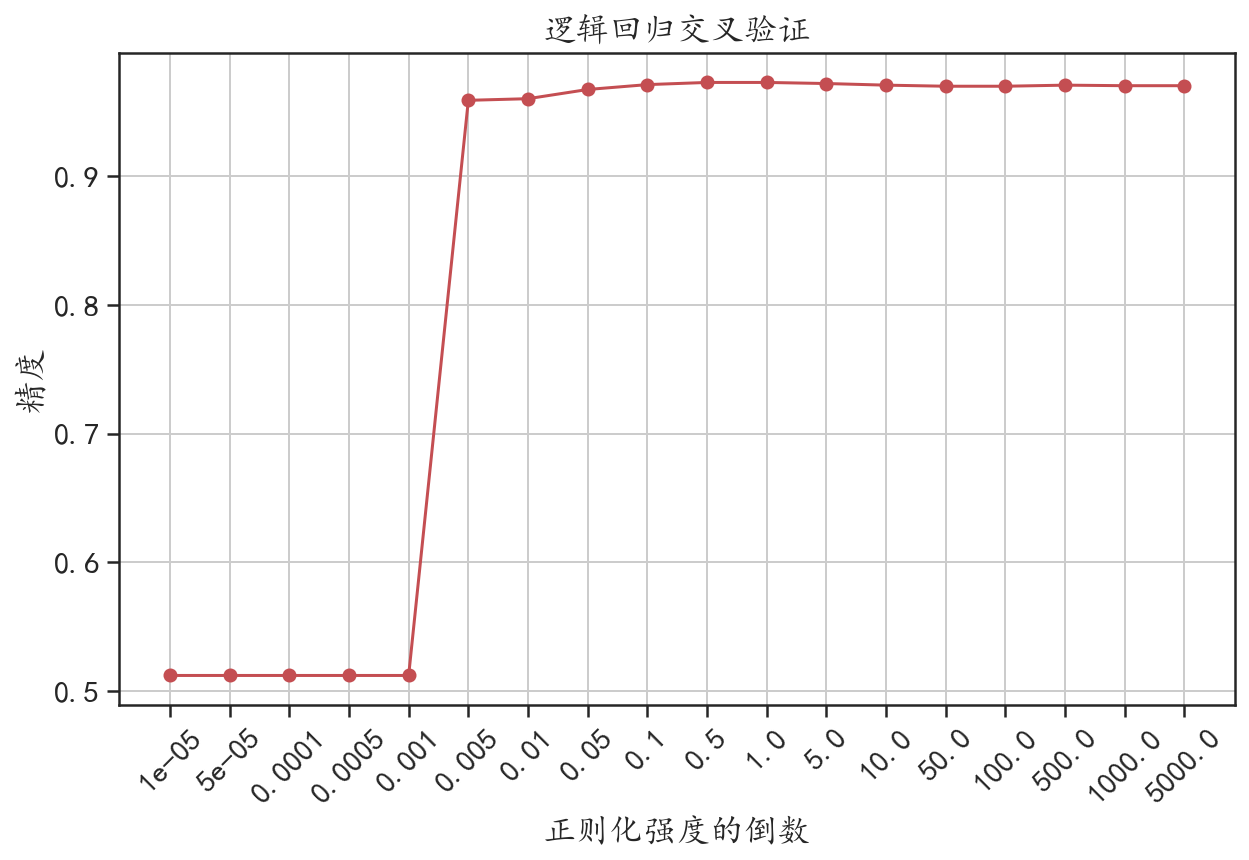

In [18]:
## 分析交叉验证的结果
mean_scores = logrcv.scores_[1].mean(axis = 0) # 平均精度
logcs = logrcv.Cs_
## 可视化不同的参数C下预测精度的大小
plt.figure(figsize=(10,6))
plt.plot(mean_scores,"r-o")
plt.xticks(range(len(logcs)),logcs,rotation = 45)
plt.xlabel("正则化强度的倒数")
plt.ylabel("精度")
plt.title("逻辑回归交叉验证")
plt.grid()
plt.show()

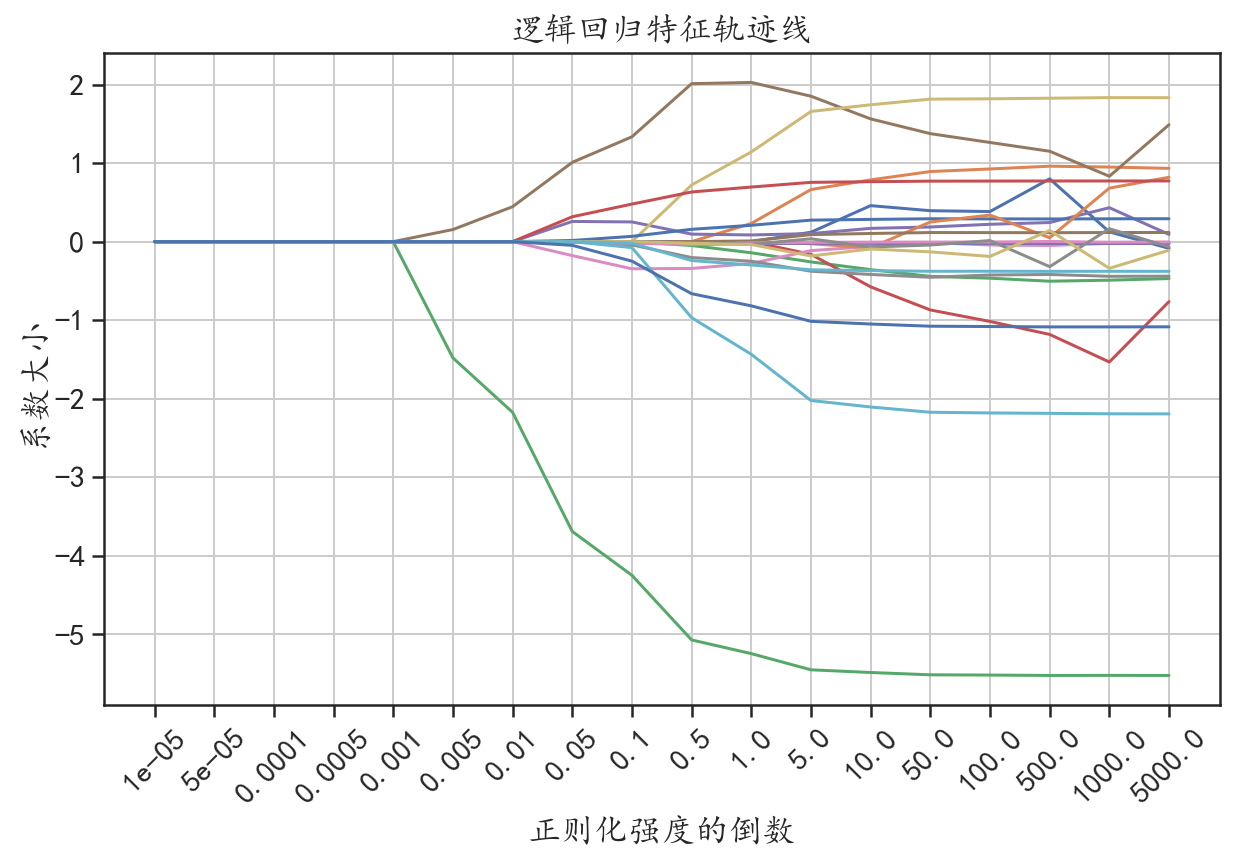

In [67]:
## 计算交叉验证的平均系数大小
mean_coefs_paths = logrcv.coefs_paths_[1].mean(axis = 0)
## 可视化每个特征的轨迹线
plt.figure(figsize=(10,6))
plt.plot(range(len(logcs)),mean_coefs_paths,"-")
plt.xticks(range(len(logcs)),logcs,rotation = 45)
plt.xlabel("正则化强度的倒数")
plt.ylabel("系数大小")
plt.title("逻辑回归特征轨迹线")
plt.grid()
plt.show()

In [68]:
## 使用最好的参数C使用所有训练数据建立逻辑回归，并对测试集进行预测
logr = LogisticRegression(C=0.5,        # 正则强度的倒数
                          penalty = "l1",  # 利用L1范数进行约束
                          solver="liblinear" ,random_state=0)
logr.fit(X_train,y_train)
print("每个特征的系数为:\n",logr.coef_)
## 输出使用了哪些特征
print("剔除的特征:\n",varname[logr.coef_.flatten() == 0])
print("保留的特征:\n",varname[logr.coef_.flatten() != 0])

每个特征的系数为:
 [[ 0.          0.         -0.06625907  0.          0.05690998  2.11073422
  -0.15755316 -0.35569364  1.00686467 -1.19837523  0.18534718  0.
  -5.1142233   0.65209797  0.          0.         -0.01235897 -0.034038
   0.         -0.27899298]]
剔除的特征:
 ['meanfreq' 'sd' 'Q25' 'centroid' 'maxfun' 'meandom' 'dfrange']
保留的特征:
 ['median' 'Q75' 'IQR' 'skew' 'kurt' 'sp.ent' 'sfm' 'mode' 'meanfun'
 'minfun' 'mindom' 'maxdom' 'modindx']


In [69]:
## 对测试集进行预测
y_pre = logr.predict(X_test)
print(classification_report(y_test,y_pre))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       367
           1       0.98      0.98      0.98       425

    accuracy                           0.98       792
   macro avg       0.98      0.98      0.98       792
weighted avg       0.98      0.98      0.98       792



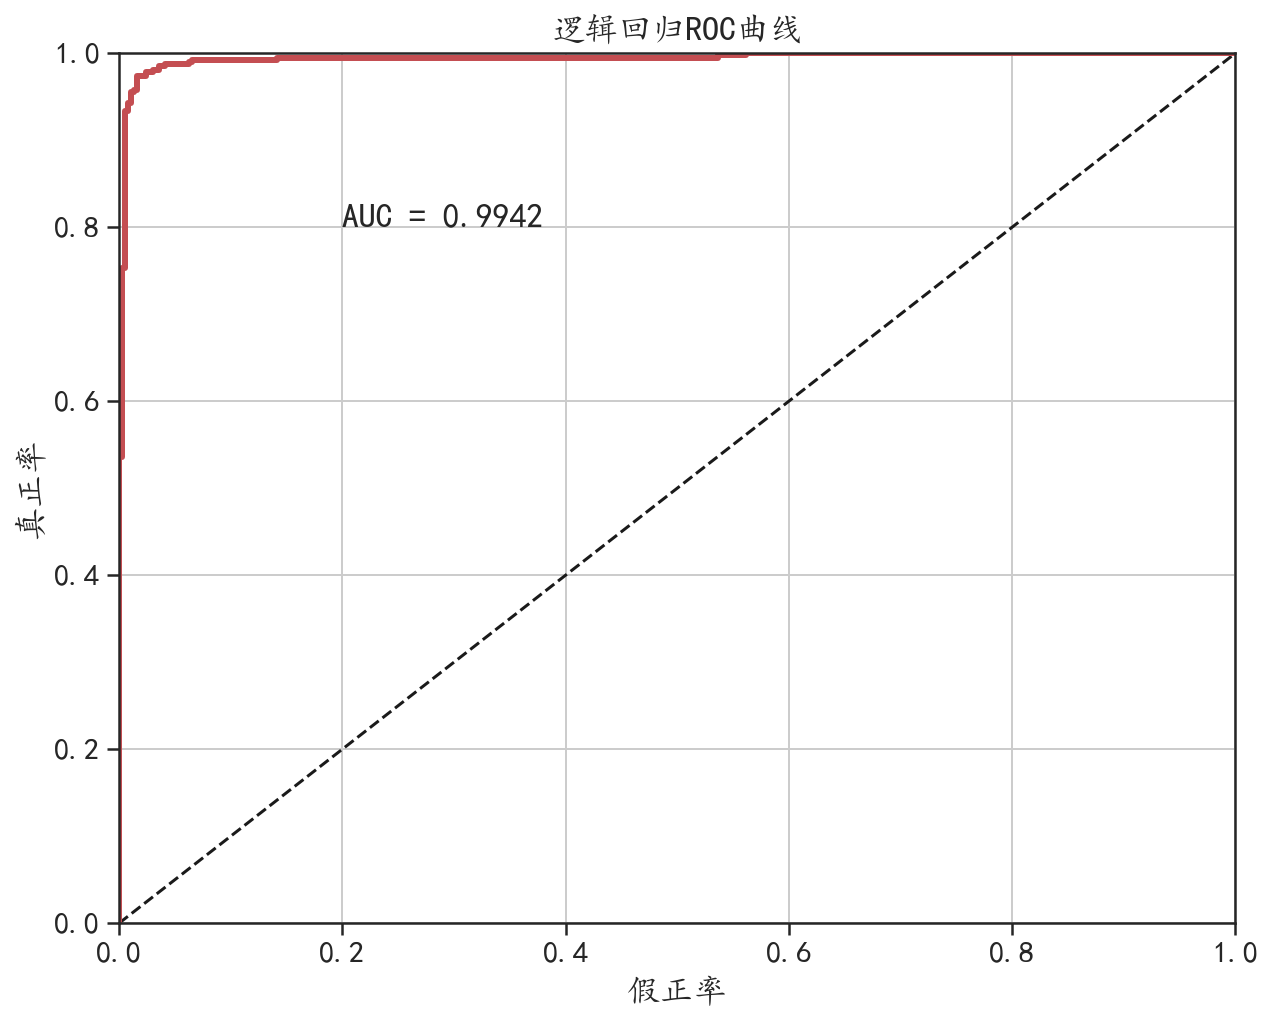

In [70]:
## 可视化在测试集上的Roc曲线
pre_y = logr.predict_proba(X_test)[:, 1]
fpr_Nb, tpr_Nb, _ = metrics.roc_curve(y_test, pre_y)
auc = metrics.auc(fpr_Nb, tpr_Nb)
plt.figure(figsize=(10,8))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_Nb, tpr_Nb,"r",linewidth = 3)
plt.grid()
plt.xlabel("假正率")
plt.ylabel("真正率")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("逻辑回归ROC曲线")
plt.text(0.2,0.8,"AUC = "+str(round(auc,4)))
plt.show()